In [1]:
# from utility.plot_spectrum import plot_spectrum
# from utility.adjust_redshift import adjust_redshift
# from utility.my_colors import palette_light, pink

# from processing.remove_spikes import remove_spikes
# from processing.fit_continuum import fit_continuum
# from processing.quality_cuts import quality_cuts
# from processing.make_bal_mask import make_bal_mask
# from processing.fit_gaussians import fit_single_gaussian, fit_two_gaussians, ftest_which_gaussian
# from processing.measure_line import measure_line
# from processing.parameters import CIV_CONTINUUM_WINDOWS
# from processing.get_absorption_intervals import get_absorption_intervals

# from data.local.hamann_erq_desi_idxs import valid_sdss_names

# from sparcl.client import SparclClient
# from dl import queryClient as qc
# from astropy.table import Table
# from astropy.convolution import convolve, Gaussian1DKernel
# from scipy.interpolate import interp1d
# from datetime import datetime
# from scipy.signal import argrelmin, argrelmax
# from ast import literal_eval

# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd
# import warnings
# import json
# import os

# hamann_fits_path = "data/local/ERQs_core_all_MNRAS.fits"
# search_log_path = "data/local/hamann-objects-desi-search-log.json"
# matched_desi_spectra_path = "data/local/matched_desi_spectra.json"

from utility.plot_spectrum import plot_spectrum
from utility.my_colors import palette_dark, palette_light
from utility.adjust_redshift import adjust_redshift

from processing.remove_spikes import remove_spikes
from processing.fit_continuum import fit_continuum
from processing.quality_cuts import quality_cuts
from processing.get_absorption_intervals import get_absorption_intervals
from processing.fit_gaussians import fit_single_gaussian, fit_two_gaussians, ftest_which_gaussian
from processing.measure_line import measure_line
from processing.parameters import CIV_CONTINUUM_WINDOWS, CIV_FIT_WINDOW, NV_LYA_CONTINUUM_WINDOWS, LYA_NV_FIT_WINDOW, CIV_AIR, LYA_AIR, NV_AIR, C_KMS
from processing.scale_civ_to_nv import scale_civ_to_nv

from astropy.table import Table

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


found_desi_spectra_stats_path = "data/found_desi_spectra_stats.json"


### preprocess

In [2]:
# hamann_data = Table.read("data/local/ERQs_core_all_MNRAS.fits").to_pandas() #pd.read_csv(hamann_erq_path,index_col=0)

# hamann_data["sdss_name"] = hamann_data["sdss_name"].astype("string")

# match_df = pd.read_json(search_log_path)
# match_df = match_df[["SDSS_id","best_match_id"]].copy()
# match_df["SDSS_id"] = match_df["SDSS_id"].str[1:]

# match_df = match_df.rename(columns={"best_match_id":"targetid", "SDSS_id":"sdss_name"})

# hamann_erq = hamann_data.merge(match_df,on="sdss_name",how="left")

# hamann_erq.info()

In [3]:
# client = SparclClient()

# idxs = [int(x) for x in hamann_erq["targetid"] if x != "Not found"]

# output_fields = ['specid', 'redshift', 'wavelength', 'flux', 'ivar', 'spectype', 'targetid', 'redshift_warning']

# spectra = client.retrieve_by_specid(idxs, dataset_list=["DESI-DR1"], include=output_fields)

In [4]:
# spectra_df = pd.DataFrame(spectra.data[1:])

# spectra_df.to_json(matched_desi_spectra_path,default_handler=str)

# spectra_df

### measure lines

In [5]:
# spectra_df = pd.read_json(matched_desi_spectra_path)

# stats_half = hamann_erq[['sdss_name', 'rew', 'fwhm', 'kt80', 'targetid']].copy()

# spectra_df["targetid"] = spectra_df["targetid"].astype("string")

# data = spectra_df.merge(stats_half,on="targetid")

# data = data[data["sdss_name"].isin(valid_sdss_names)]

# data = data.drop_duplicates(subset="sdss_name")

# data.to_json(found_desi_spectra_stats_path)

In [6]:
data = pd.read_json(found_desi_spectra_stats_path)
data = data.reset_index(drop=True)

# set up stats dataframe
stats = Table.read("data/local/ERQs_core_all_MNRAS.fits").to_pandas()
stats["sdss_name"] = stats["sdss_name"].astype("string")
stats = stats[["sdss_name","rew","rew_nv","fwhm","kt80"]].copy()
stats = stats.set_index("sdss_name")
stats = stats.rename(columns={"rew":"civ_rew_hamann","rew_nv":"nv_rew_hamann","fwhm":"civ_fwhm_hamann","kt80":"civ_kt80_hamann"})

stats["civ_fwhm_mine"] = None
stats["civ_kt80_mine"] = None
stats["civ_rew_mine"], stats["nv_rew_mine"], stats["lya_rew_mine"] = None, None, None
stats["civ_fit_rew_mine"], stats["nv_fit_rew_mine"], stats["lya_fit_rew_mine"] = None, None, None

In [7]:
def test(idx):    
    lam = np.array(data["wavelength"][idx])
    flux = np.array(data["flux"][idx])
    ivar = np.array(data["ivar"][idx])
    z = data["redshift"][idx]


    ## ADJUST REDSHIFT
    lam, flux, ivar = adjust_redshift(z, lam, flux, ivar=ivar)


    ## EXTRACT VALID PIXELS & REMOVE OUTLIERS

    # mask bad pixels, i.e. pixels where flux is zero, ivar is zero or infinity
    valid_pixel_mask = ((lam > 1150) & (lam < 1810)) & (ivar > 0) & np.isfinite(ivar) & (flux != 0)

    # apply mask
    lam = lam[valid_pixel_mask]
    flux = flux[valid_pixel_mask]
    ivar = ivar[valid_pixel_mask]

    # create noise
    noise = np.abs(1/np.sqrt(ivar))

    # remove spikes
    flux_clean, _ = remove_spikes(lam,flux,ivar=ivar)


    ## FIT CONTINUUM BELOW CIV
    result_civ_cont, continuum_civ, _ = fit_continuum(lam, flux_clean, ivar=ivar, windows=CIV_CONTINUUM_WINDOWS, lambda_ref=1700.0)


    ## QUALITY CUTS (based on CIV region)

    # TODO: fix all this, like i think it doesnt do shit currently and you need to get the values fixed
    rejected, reason, flags = quality_cuts(lam, flux_clean, continuum_civ, result_civ_cont, max_slope=10.0)

    if rejected:
        print(f'Rejected because: {reason}')
        
    else:
        ## FIT CIV LINE

        # subtract CIV continuum
        flux_sub_civ = flux_clean - continuum_civ if not rejected else None

        # get absorption mask
        _, civ_absorption_mask = get_absorption_intervals(lam,flux_sub_civ,noise,continuum_civ, window=CIV_FIT_WINDOW)
        # civ_absorption_mask = (flux_sub_civ < -noise)

        # fit single gaussian, use result as parameter guesses for two gaussian fit
        result1_civ, profile1_civ = fit_single_gaussian(lam, flux_sub_civ, ivar=ivar, mask=civ_absorption_mask, window=CIV_FIT_WINDOW)
        result2_civ, profile2_civ = fit_two_gaussians(lam, flux_sub_civ, ivar=ivar, mask=civ_absorption_mask, single_result=result1_civ, window=CIV_FIT_WINDOW)

        # F-test which fit is better
        accept_two_civ, p_val_civ = ftest_which_gaussian(result1_civ, result2_civ)

        # depending on F-test result, assign respective profile and best parameter dictionary to general variables
        profile_civ = profile2_civ if accept_two_civ else profile1_civ
        params_dict_civ = result2_civ.params.valuesdict() if accept_two_civ else result1_civ.params.valuesdict()


        ## CONTINUUM BELOW NV AND LYA
        _, continuum_nv_lya, _ = fit_continuum(lam, flux_clean, ivar=ivar, windows=NV_LYA_CONTINUUM_WINDOWS+CIV_CONTINUUM_WINDOWS, lambda_ref=1290.0)  # fit continuum
        flux_sub_nv_lya = flux_clean - continuum_nv_lya  # subtract continuum


        ## NV PROFILE

        # make LYA mask
        # idea: mask left and right by a certain fixed window (left: 60% of lam(NV)-lam(LYA), right 40%),
        # then shift by the difference between CIV fit peak and air wavelengths to make it more robust in case of bad redshift values
        diff_civ = lam[np.argmax(profile_civ)] - CIV_AIR
        m = (NV_AIR-LYA_AIR)
        c = LYA_AIR + diff_civ
        lims = (c-0.6*m,c+0.5*m)
        lya_mask = (lam > lims[0]) & (lam < lims[1])
        
        # fit NV by scaling CIV template
        _, profile_nv = scale_civ_to_nv(lam,flux_sub_nv_lya,params_dict_civ,accept_two_civ,ivar=ivar,mask=lya_mask)
        

        ## LYA PROFILE

        # subtract NV profile
        flux_sub_lya = flux_sub_nv_lya - profile_nv

        # get absorption mask
        _, lya_absorption_mask = get_absorption_intervals(lam,flux_sub_lya,continuum_nv_lya,noise,window=LYA_NV_FIT_WINDOW)  # first is intervals for plotting

        # fit single gaussian, use result as parameter guesses for two gaussian fit
        result1_lya, profile1_lya = fit_single_gaussian(lam, flux_sub_lya, ivar=ivar, mask=lya_absorption_mask, window=LYA_NV_FIT_WINDOW)
        result2_lya, profile2_lya = fit_two_gaussians(lam, flux_sub_lya, ivar=ivar, mask=lya_absorption_mask, single_result=result1_lya, window=LYA_NV_FIT_WINDOW)

        # F-test which fit is better, assign to general variable
        accept_two_lya, p_val_lya = ftest_which_gaussian(result1_lya, result2_lya)
        profile_lya = profile2_lya if accept_two_lya else profile1_lya


        ## LINE MEASUREMENT

        # CIV
        line_stats_civ, civ_integration_win = measure_line(lam, profile_civ, flux_sub_civ, continuum_civ, window=CIV_FIT_WINDOW,get_window=True) 

        # NV
        flux_sub_nv = flux_sub_nv_lya - profile_lya  # subtract Lya profile
        line_stats_nv, nv_integration_win = measure_line(lam,profile_nv,flux_sub_nv,continuum_nv_lya,window=LYA_NV_FIT_WINDOW,get_window=True)

        # Lya
        line_stats_lya, lya_integration_win = measure_line(lam,profile_lya,flux_sub_lya,continuum_nv_lya,window=LYA_NV_FIT_WINDOW,get_window=True)
        

        ## RESULTS

        # extract
        sdss_name = data["sdss_name"][idx]

        rew_civ = line_stats_civ["ew_aa"]
        rew_nv = line_stats_nv["ew_aa"]
        rew_lya = line_stats_lya["ew_aa"]

        # print
        print(f'''
            SDSS: {sdss_name}

            Lya:\t{rew_lya:.3f}
            NV:\t\t{rew_nv:.3f}\t{stats.loc[sdss_name,"nv_rew_hamann"]:.3f} (Hamann)
            CIV:\t{rew_civ:.3f}\t{stats.loc[sdss_name,"civ_rew_hamann"]:.3f} (Hamann)
            
            compared to CIV:
            Lya\t\tNV\tCIV
            {(rew_lya/rew_civ):.2f}\t{(rew_nv/rew_civ):.2f}\t1
        ''')

        # to dataframe
        stats.loc[sdss_name,"civ_rew_mine"] = rew_civ
        stats.loc[sdss_name,"nv_rew_mine"] = rew_nv
        stats.loc[sdss_name,"lya_rew_mine"] = rew_lya
        
        stats.loc[sdss_name,"civ_fit_rew_mine"] = line_stats_civ["fit_rew"]
        stats.loc[sdss_name,"nv_fit_rew_mine"] = line_stats_nv["fit_rew"]
        stats.loc[sdss_name,"lya_fit_rew_mine"] = line_stats_lya["fit_rew"]

        stats.loc[sdss_name,"civ_fwhm_mine"] = line_stats_civ["fwhm_kms"]
        stats.loc[sdss_name,"civ_kt80_mine"] = line_stats_civ["kt80"]


        ## PLOTTING

        plot_mask_lya_nv = (lam > LYA_NV_FIT_WINDOW[0]) & (lam < LYA_NV_FIT_WINDOW[1])

        if nv_integration_win is not None:
            plot_spectrum(lam[plot_mask_lya_nv],flux_sub_nv_lya[plot_mask_lya_nv],
                # line profiles
                additional_flux=[profile_lya[plot_mask_lya_nv],profile_nv[plot_mask_lya_nv]],
                additional_flux_label=[r"Ly$\alpha$ fit","NV fit"],
                additional_flux_color=["#4b0082","#007090"],
                # absorption
                scatter_x=lam[lya_absorption_mask],
                scatter_y=flux_sub_nv_lya[lya_absorption_mask],
                scatter_label="absorption detected",
                # integration regions
                shaded_regions=[lya_integration_win,nv_integration_win,lims],
                shaded_regions_colors=["#d9ace3","#adcae3","grey"],
                shaded_regions_label=[r"Ly$\alpha$ integration window","NV integration window",r"Ly$\alpha$ mask"],
                # lines
                line_lambda=[LYA_AIR,NV_AIR],
                line_label=[r"Ly$\alpha$","NV"],
                line_color=palette_dark[1:3],
                # general
                line_width_factor=2
            )
        else:
            plot_spectrum(lam[plot_mask_lya_nv],flux_sub_nv_lya[plot_mask_lya_nv],
                # line profiles
                additional_flux=[profile_lya[plot_mask_lya_nv],profile_nv[plot_mask_lya_nv]],
                additional_flux_label=[r"Ly$\alpha$ fit","NV fit"],
                additional_flux_color=["#4b0082","#007090"],
                # absorption
                scatter_x=lam[lya_absorption_mask],
                scatter_y=flux_sub_nv_lya[lya_absorption_mask],
                scatter_label="absorption detected",
                # integration regions
                shaded_regions=[lya_integration_win,lims],
                shaded_regions_colors=["#d9ace3","grey"],
                shaded_regions_label=[r"Ly$\alpha$ integration window",r"Ly$\alpha$ mask"],
                # lines
                line_lambda=[LYA_AIR,NV_AIR],
                line_label=[r"Ly$\alpha$","NV"],
                line_color=palette_dark[1:3],
                # general
                line_width_factor=2
            )
        

        plot_mask_civ = (lam > CIV_FIT_WINDOW[0]) & (lam < CIV_FIT_WINDOW[1])

        plot_spectrum(lam[plot_mask_civ],flux_sub_civ[plot_mask_civ],
            # line profiles
            additional_flux=[profile_civ[plot_mask_civ]],
            additional_flux_label=["CIV fit"],
            additional_flux_color=["#6b8e23"],
            # absorption
            scatter_x=lam[civ_absorption_mask],
            scatter_y=flux_sub_civ[civ_absorption_mask],
            scatter_label="absorption detected",
            # integration regions
            shaded_regions=[civ_integration_win],
            shaded_regions_colors=["#d3ff8d"],
            # lines
            line_lambda=[CIV_AIR],
            line_label=["CIV"],
            line_color=[palette_dark[3]],
            # general
            line_width_factor=2
        )

---------------------------------------
---------------------------------------

            SDSS: 233636.99+065231.0

            Lya:	159.353
            NV:		183.111	124.533 (Hamann)
            CIV:	158.144	128.271 (Hamann)
            
            compared to CIV:
            Lya		NV	CIV
            1.01	1.16	1
        


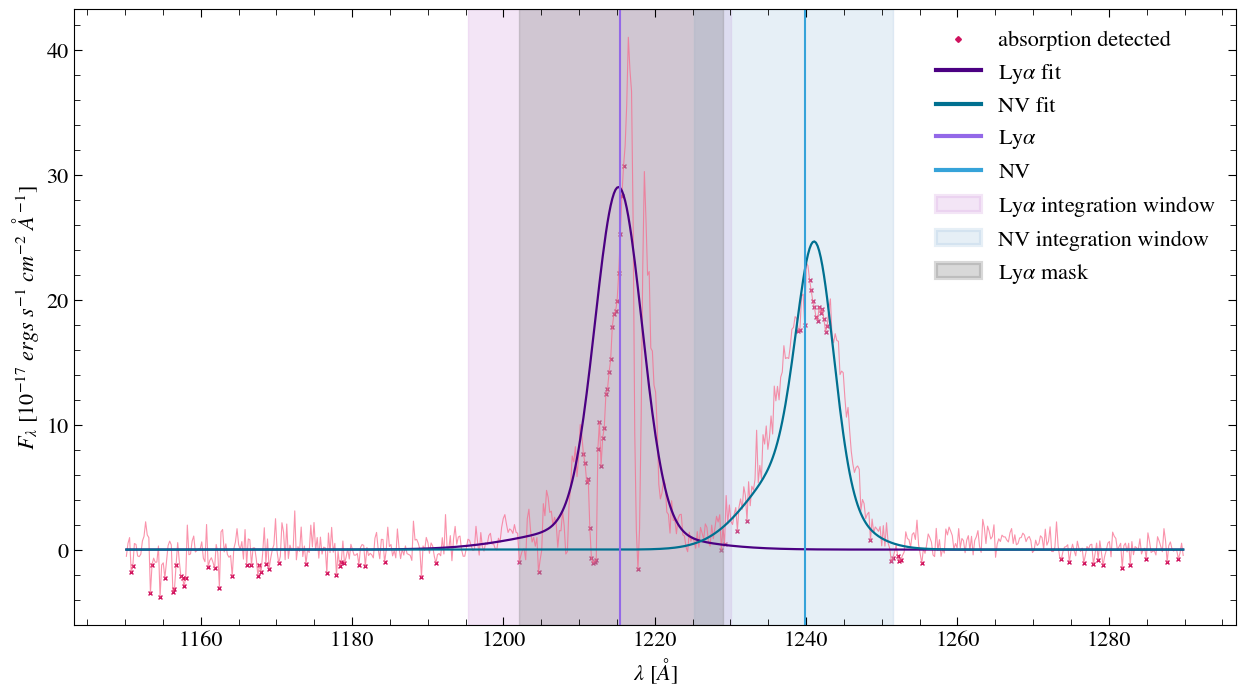

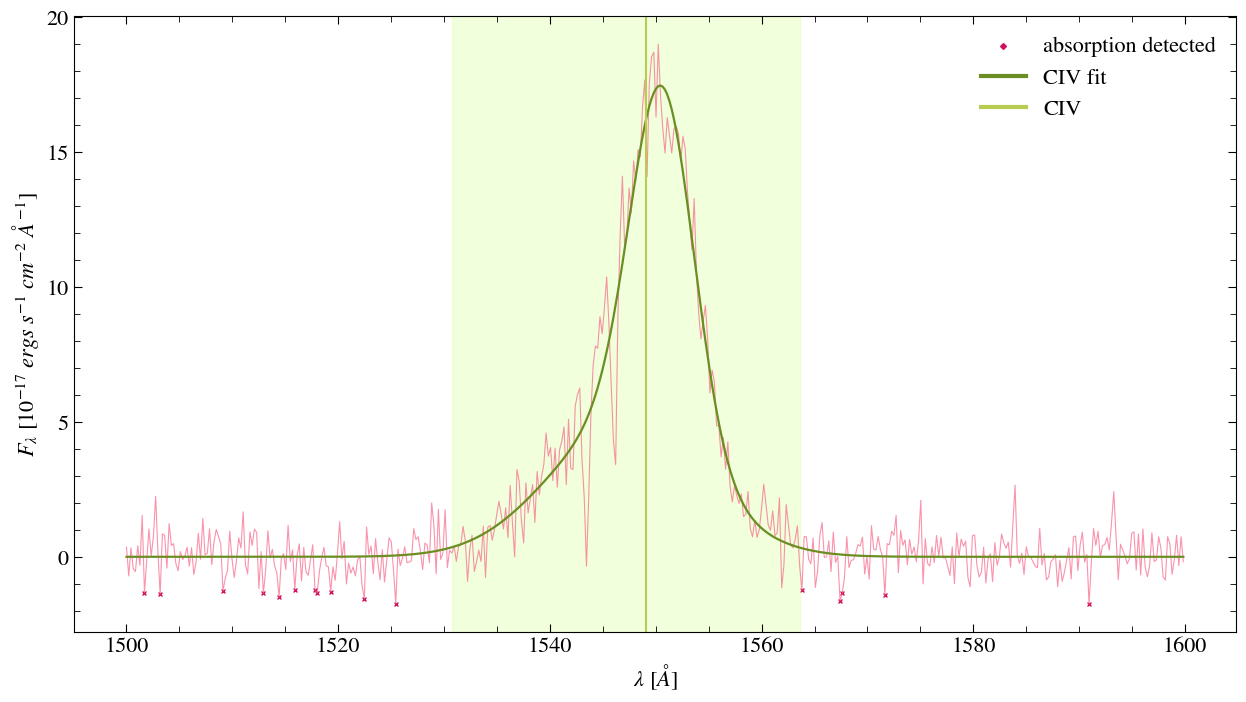

---------------------------------------
---------------------------------------

            SDSS: 082649.30+163945.2

            Lya:	65.940
            NV:		41.215	99.313 (Hamann)
            CIV:	110.656	204.888 (Hamann)
            
            compared to CIV:
            Lya		NV	CIV
            0.60	0.37	1
        


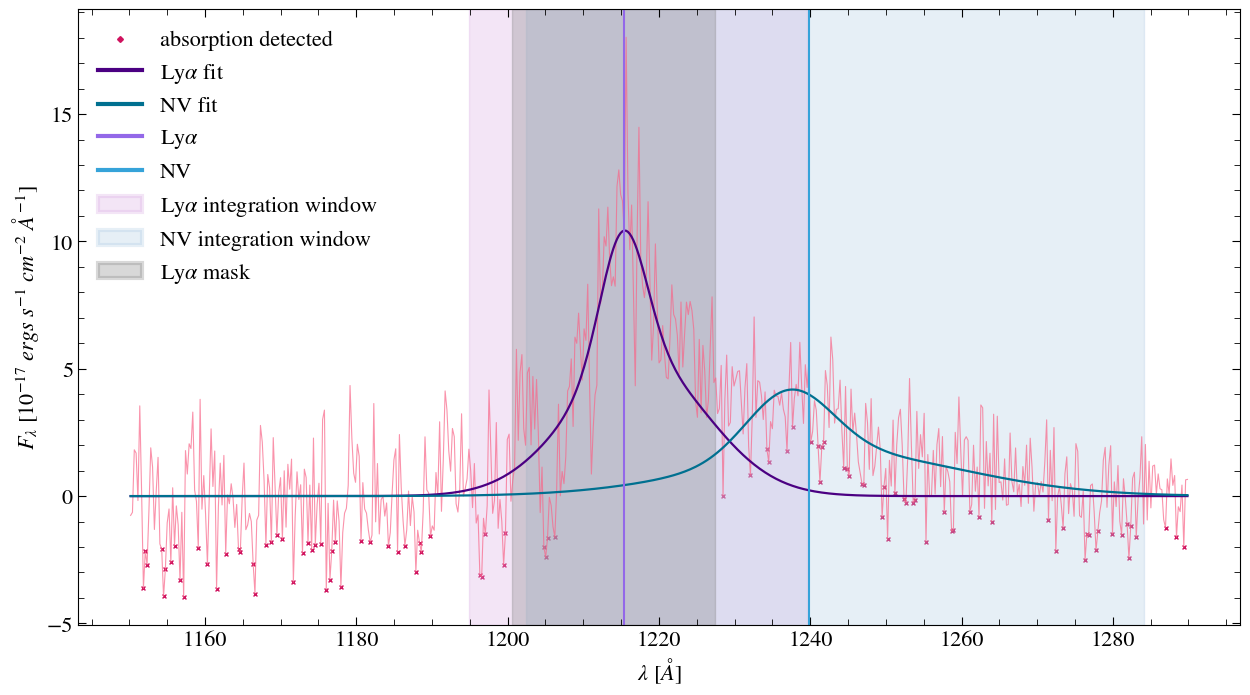

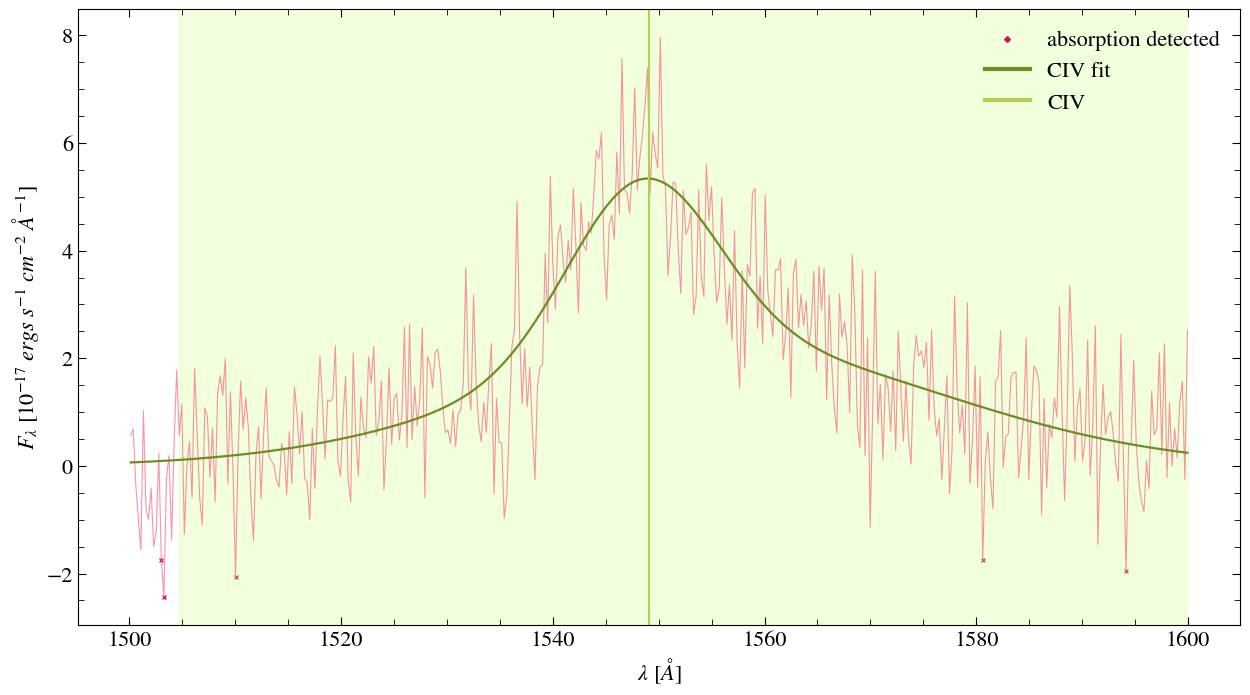

---------------------------------------
---------------------------------------

            SDSS: 083448.48+015921.1

            Lya:	1157.584
            NV:		329.997	305.821 (Hamann)
            CIV:	247.785	209.440 (Hamann)
            
            compared to CIV:
            Lya		NV	CIV
            4.67	1.33	1
        


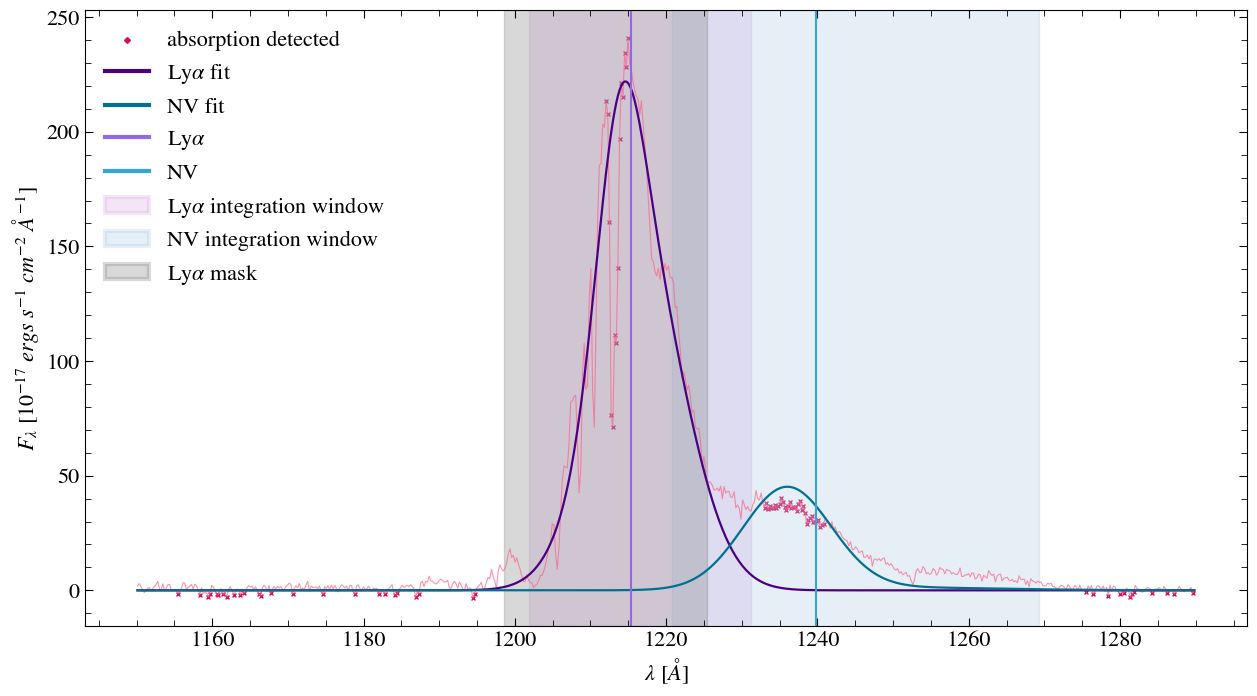

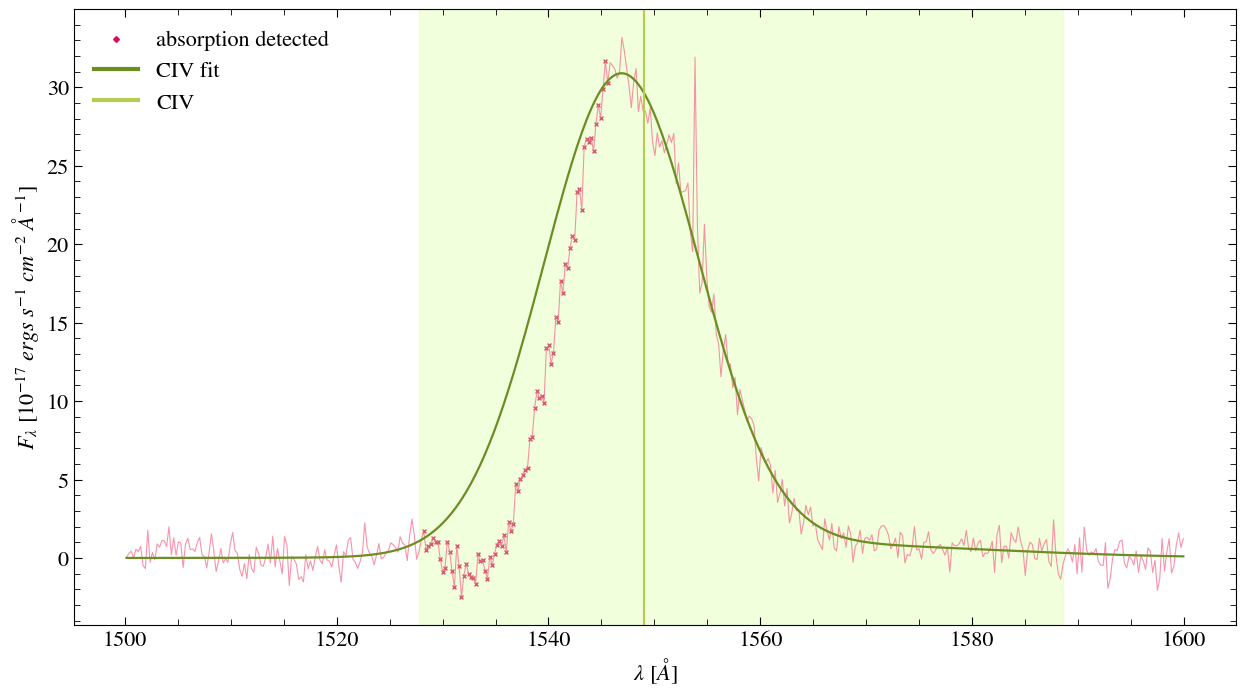

---------------------------------------
---------------------------------------

            SDSS: 131722.85+322207.5

            Lya:	197.773
            NV:		266.969	315.069 (Hamann)
            CIV:	160.830	159.850 (Hamann)
            
            compared to CIV:
            Lya		NV	CIV
            1.23	1.66	1
        


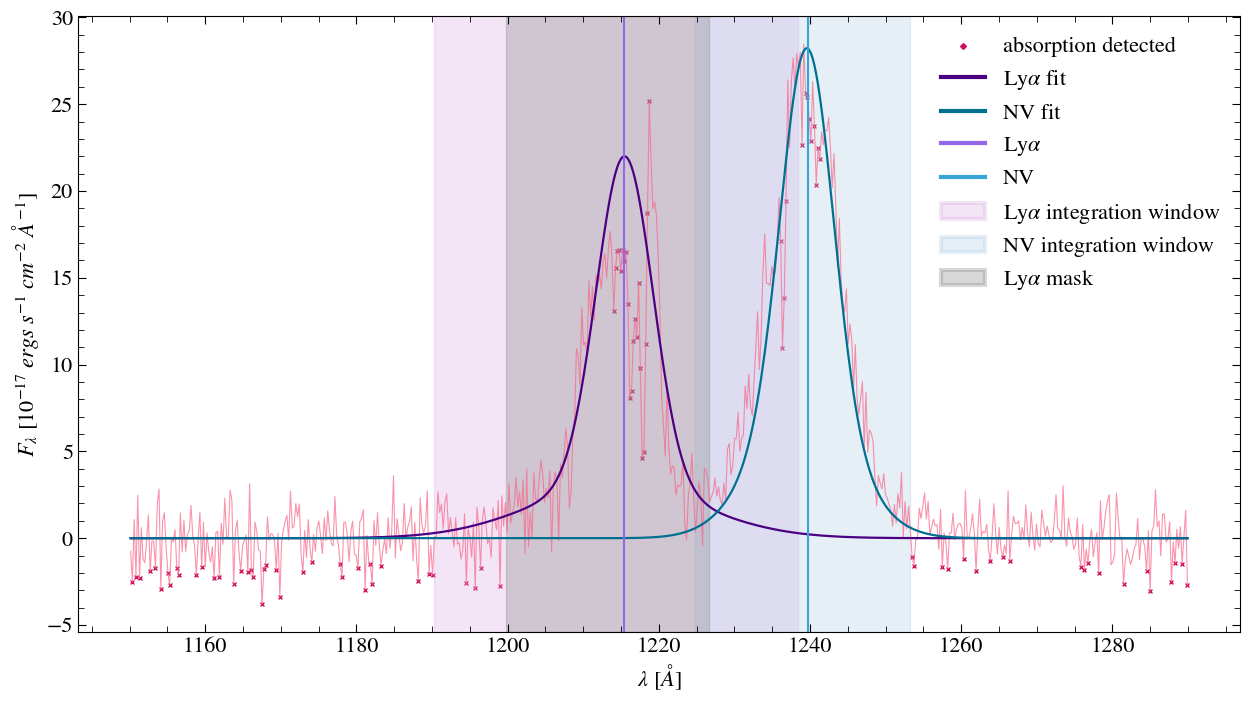

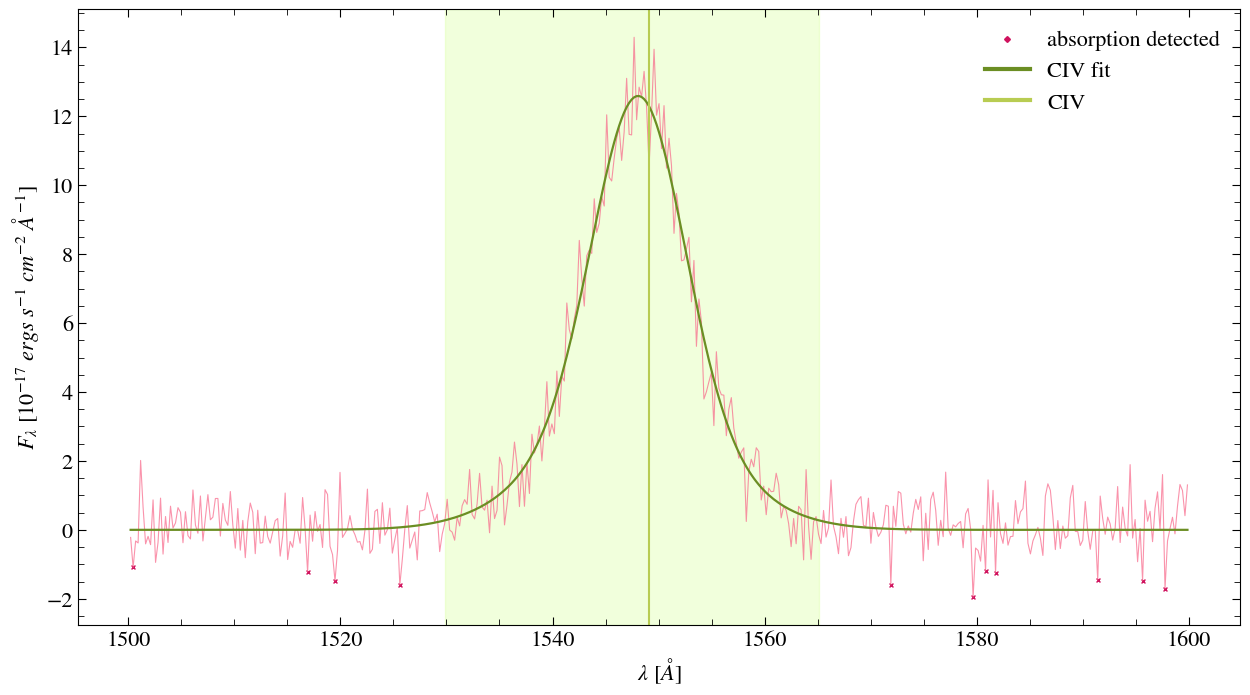

---------------------------------------
---------------------------------------

            SDSS: 082536.31+200040.3

            Lya:	83.445
            NV:		19.378	52.193 (Hamann)
            CIV:	90.317	210.805 (Hamann)
            
            compared to CIV:
            Lya		NV	CIV
            0.92	0.21	1
        


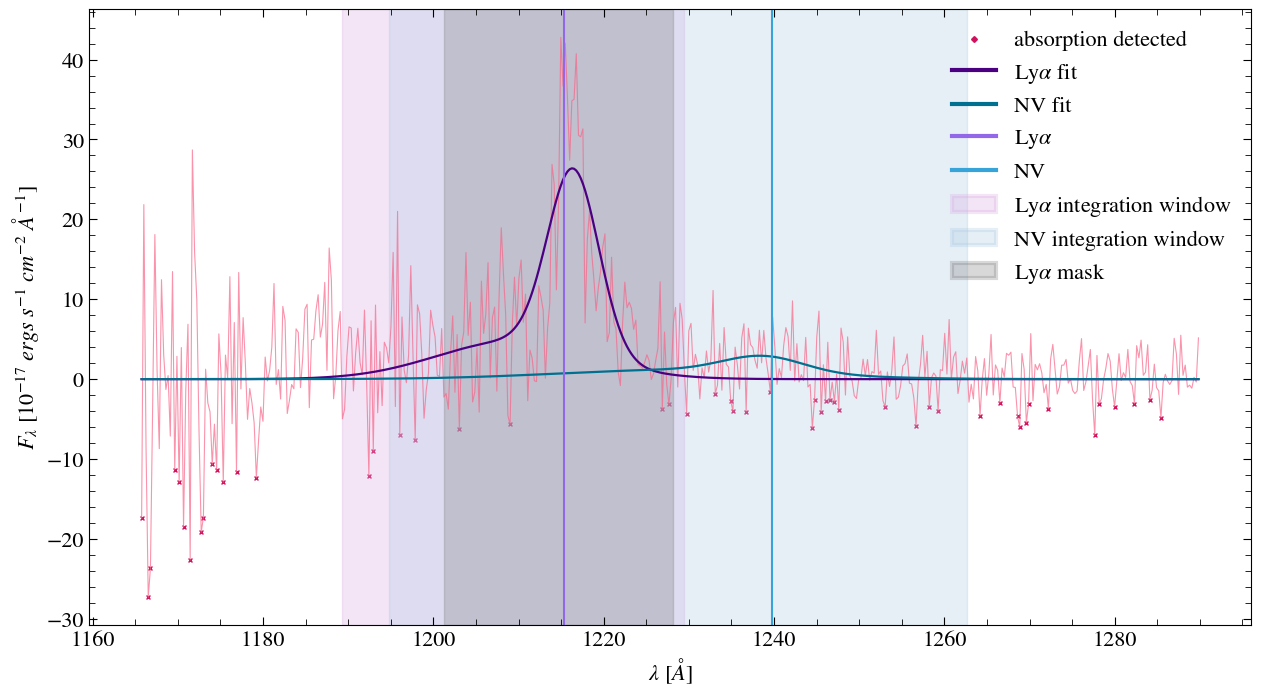

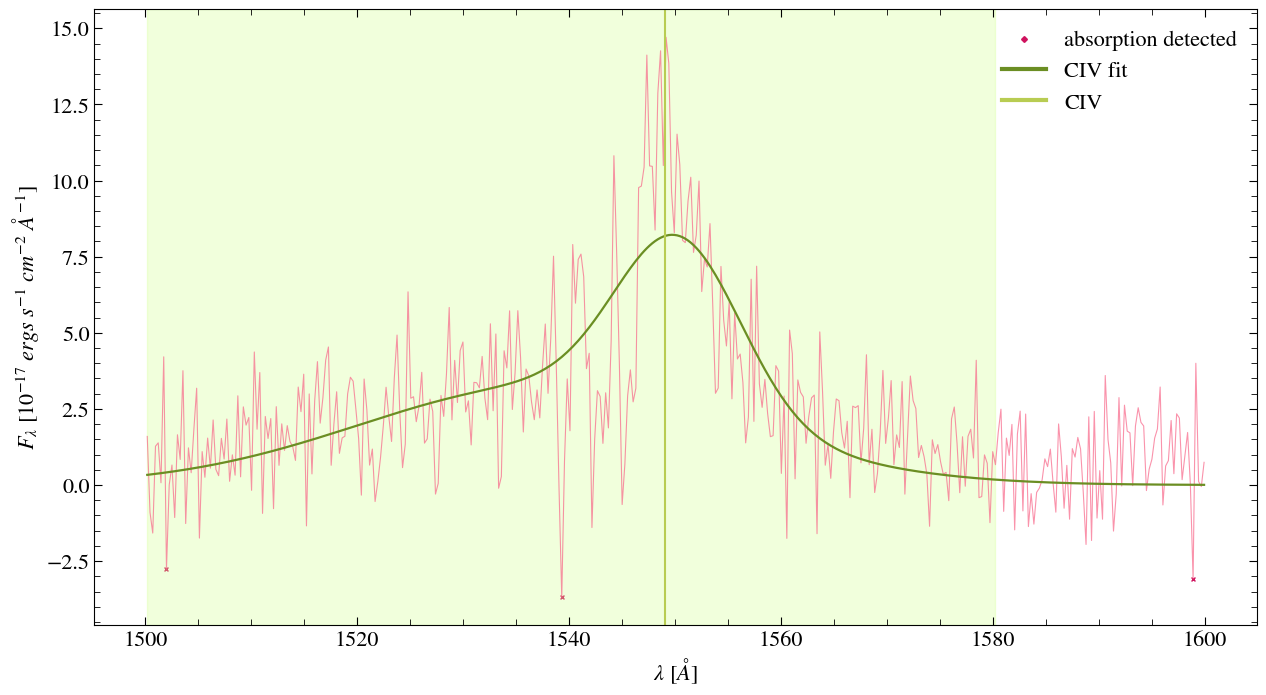

---------------------------------------
---------------------------------------

            SDSS: 130936.14+560111.3

            Lya:	210.428
            NV:		207.220	237.272 (Hamann)
            CIV:	182.079	160.873 (Hamann)
            
            compared to CIV:
            Lya		NV	CIV
            1.16	1.14	1
        


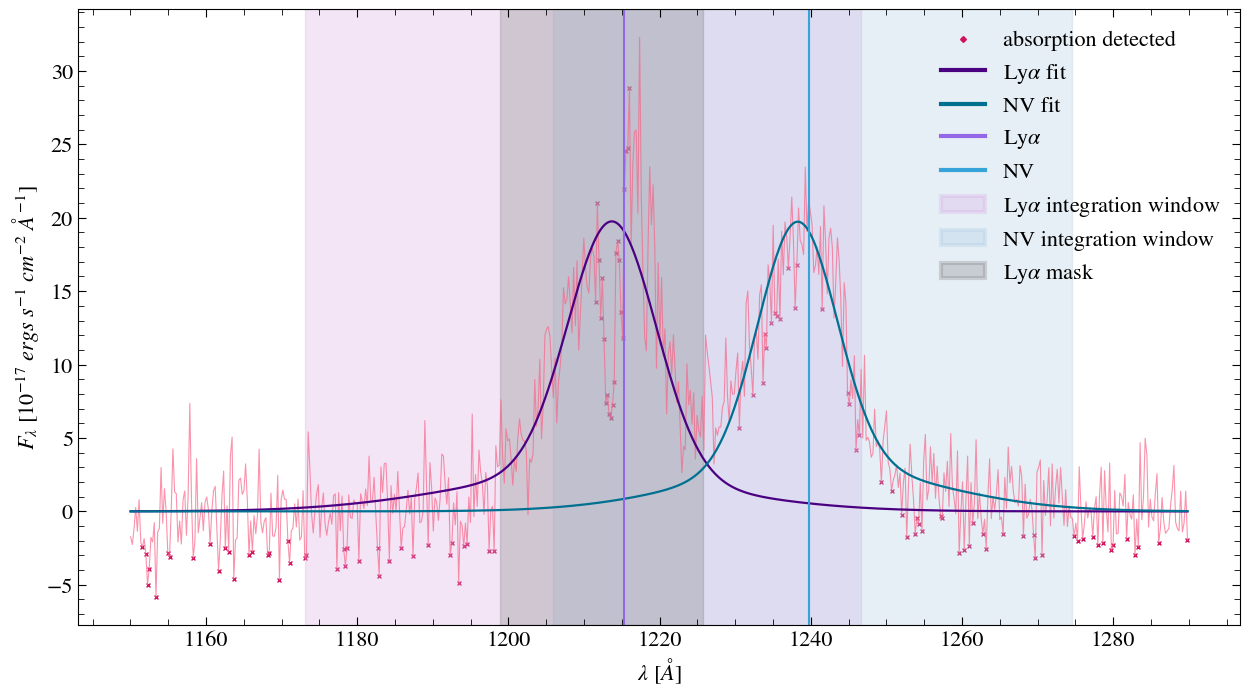

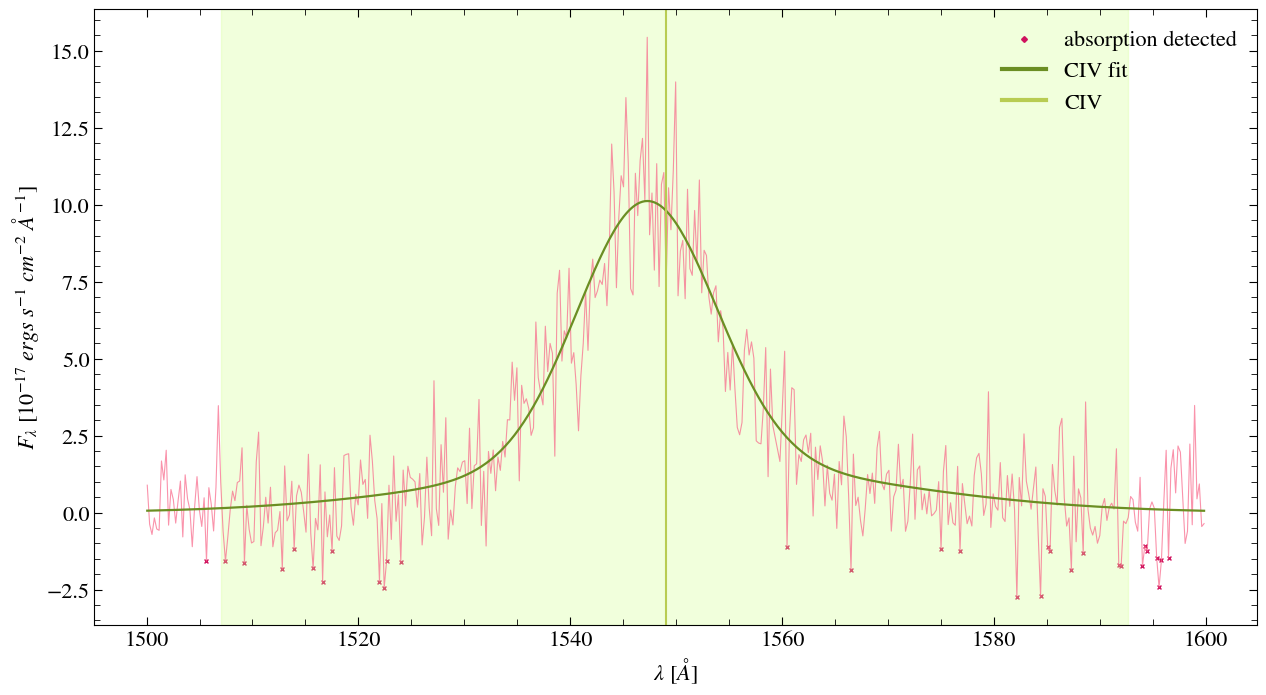

---------------------------------------
---------------------------------------

            SDSS: 002400.25+245031.9

            Lya:	70.416
            NV:		206.768	205.777 (Hamann)
            CIV:	142.788	143.690 (Hamann)
            
            compared to CIV:
            Lya		NV	CIV
            0.49	1.45	1
        


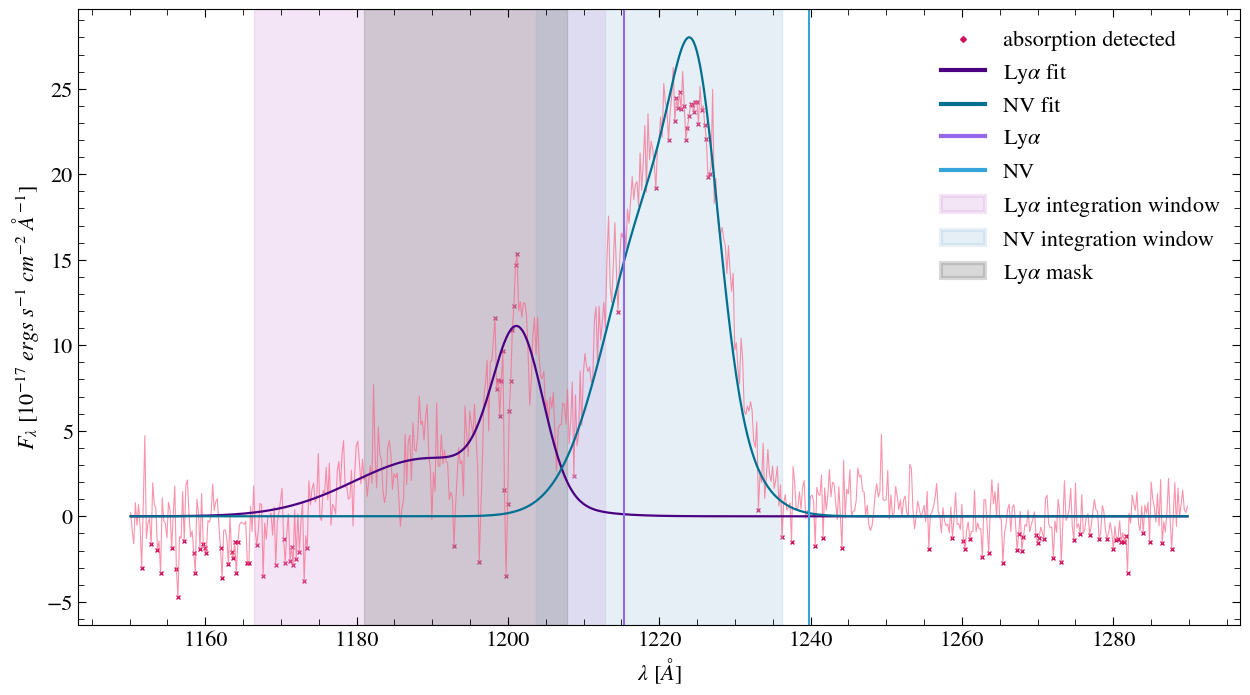

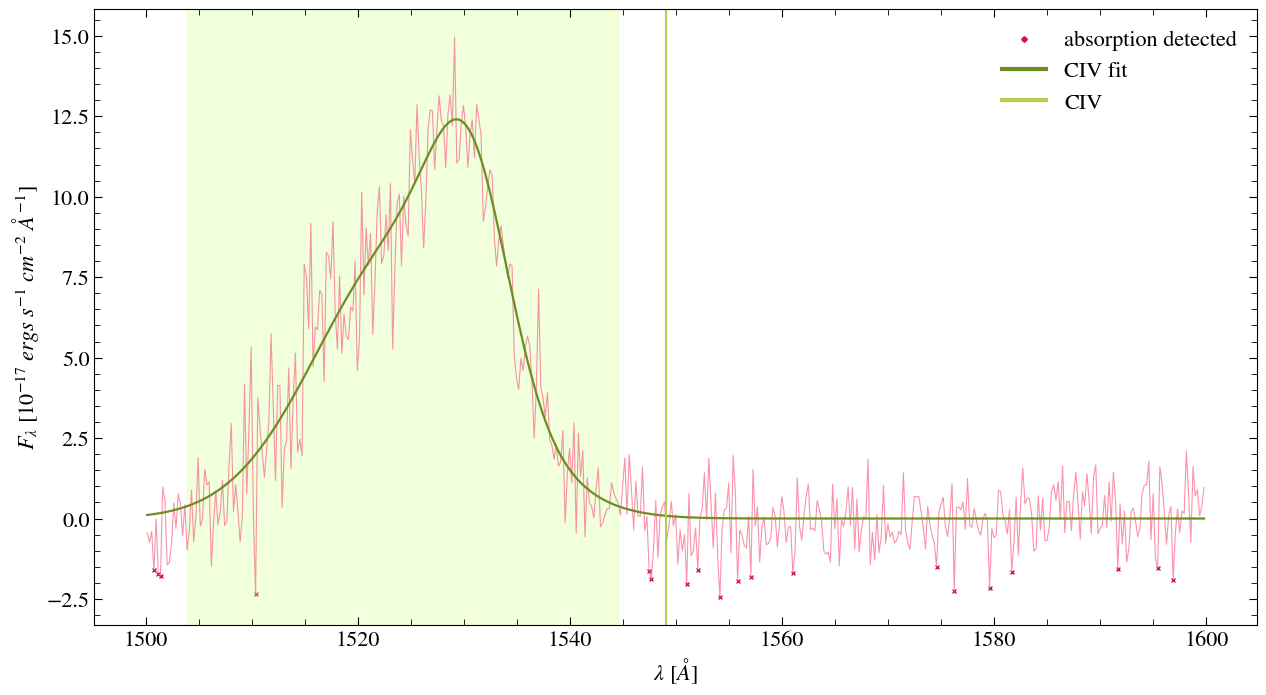

---------------------------------------
---------------------------------------

            SDSS: 134026.99+083427.2

            Lya:	353.952
            NV:		354.755	726.943 (Hamann)
            CIV:	239.520	357.973 (Hamann)
            
            compared to CIV:
            Lya		NV	CIV
            1.48	1.48	1
        


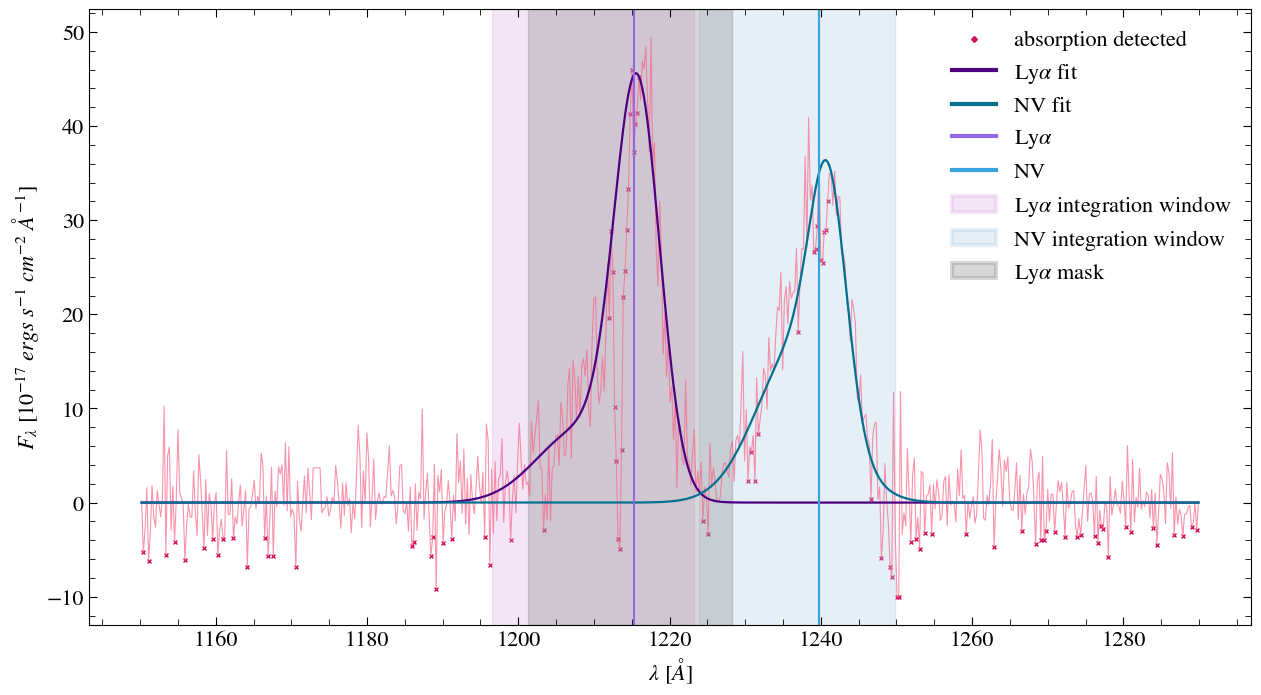

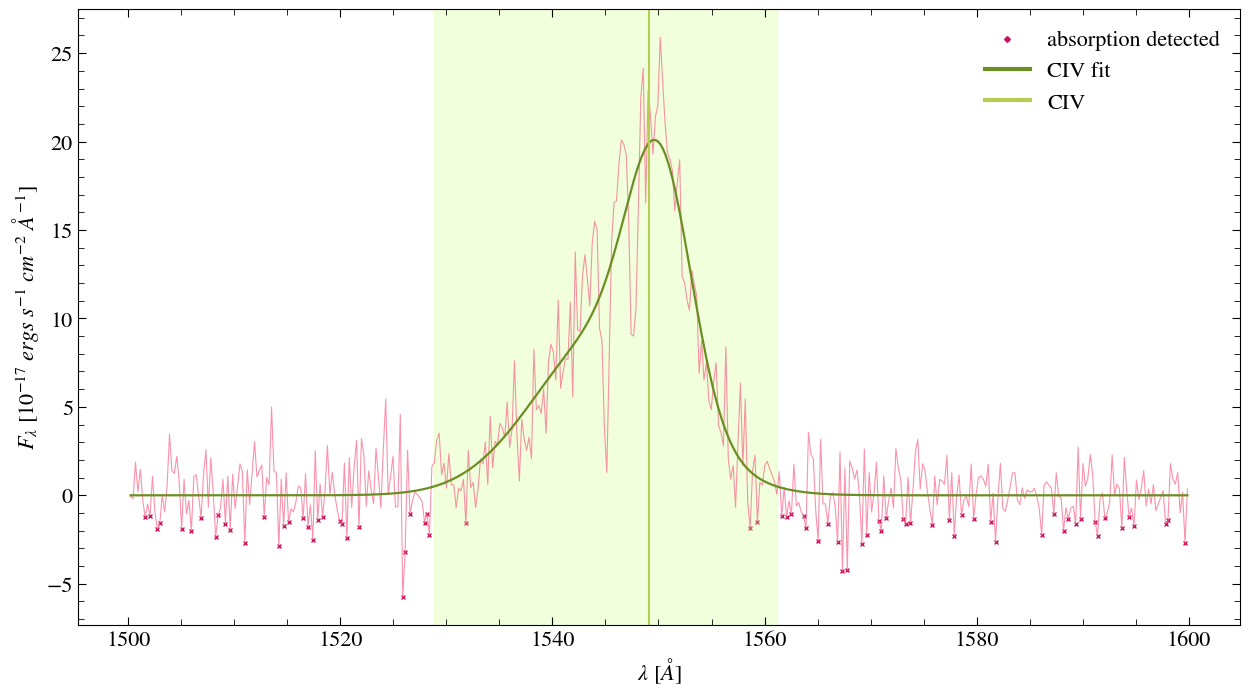

---------------------------------------
---------------------------------------

            SDSS: 134001.90+322155.9

            Lya:	234.249
            NV:		123.272	107.481 (Hamann)
            CIV:	108.662	130.709 (Hamann)
            
            compared to CIV:
            Lya		NV	CIV
            2.16	1.13	1
        


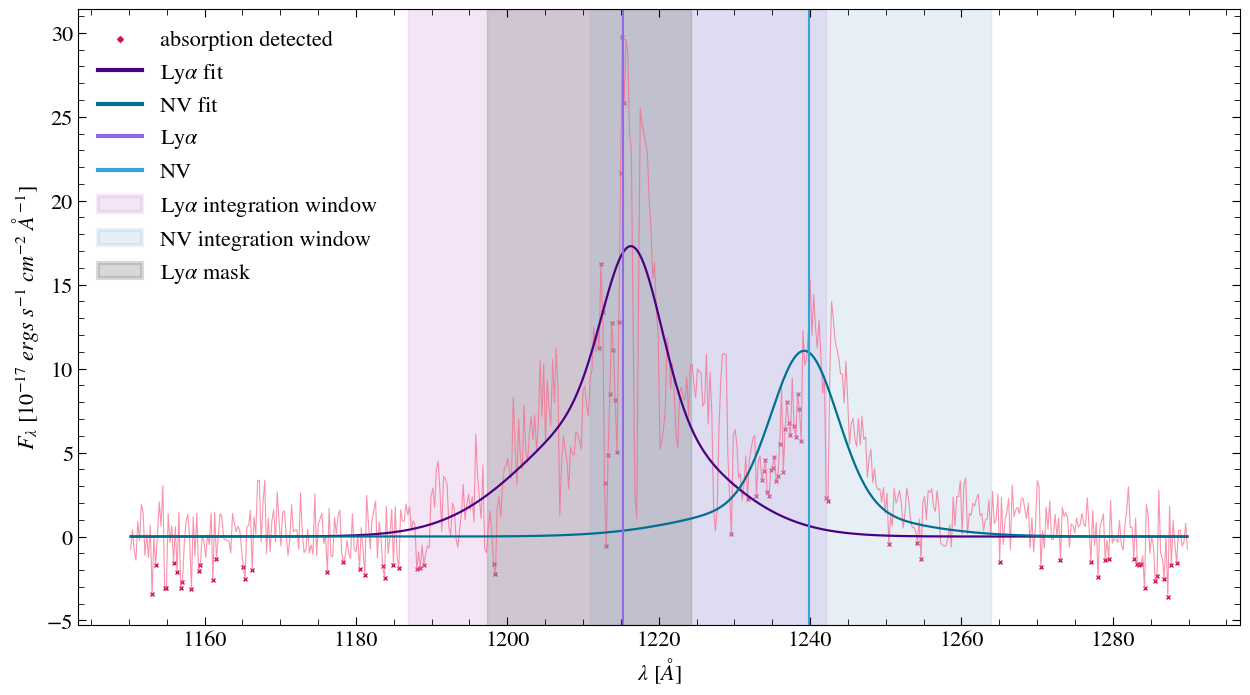

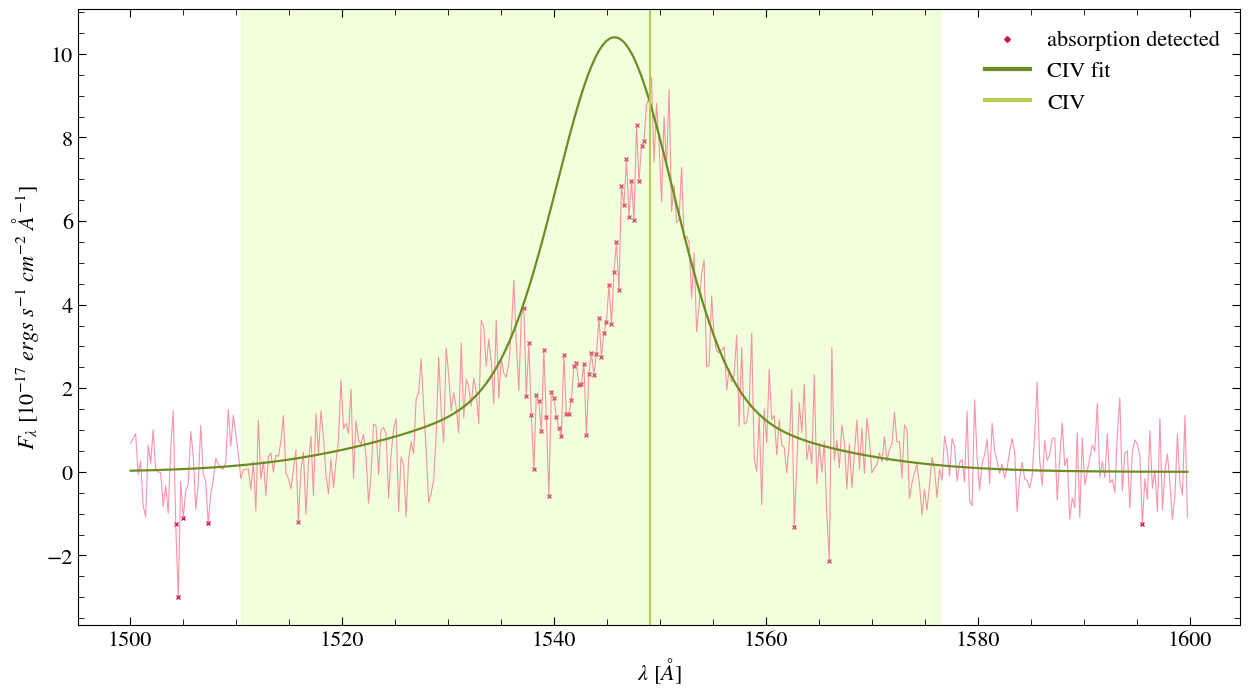

---------------------------------------
---------------------------------------

            SDSS: 104611.50+024351.6

            Lya:	91.055
            NV:		203.004	340.752 (Hamann)
            CIV:	187.169	217.582 (Hamann)
            
            compared to CIV:
            Lya		NV	CIV
            0.49	1.08	1
        


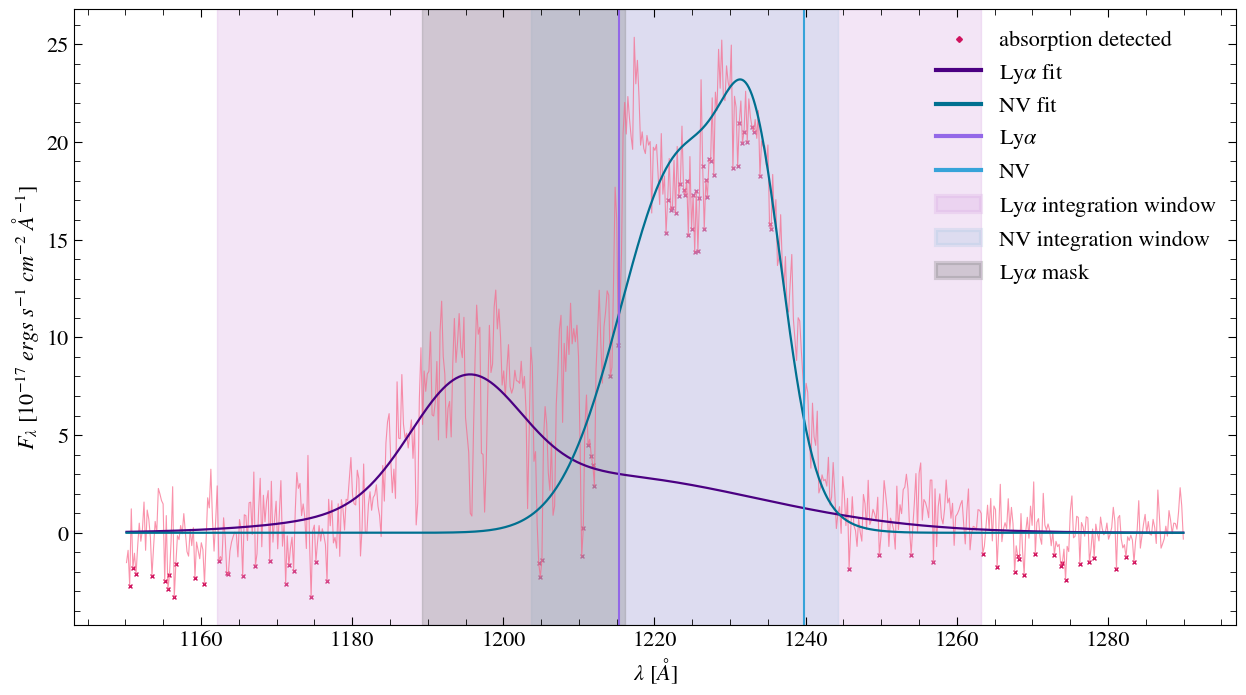

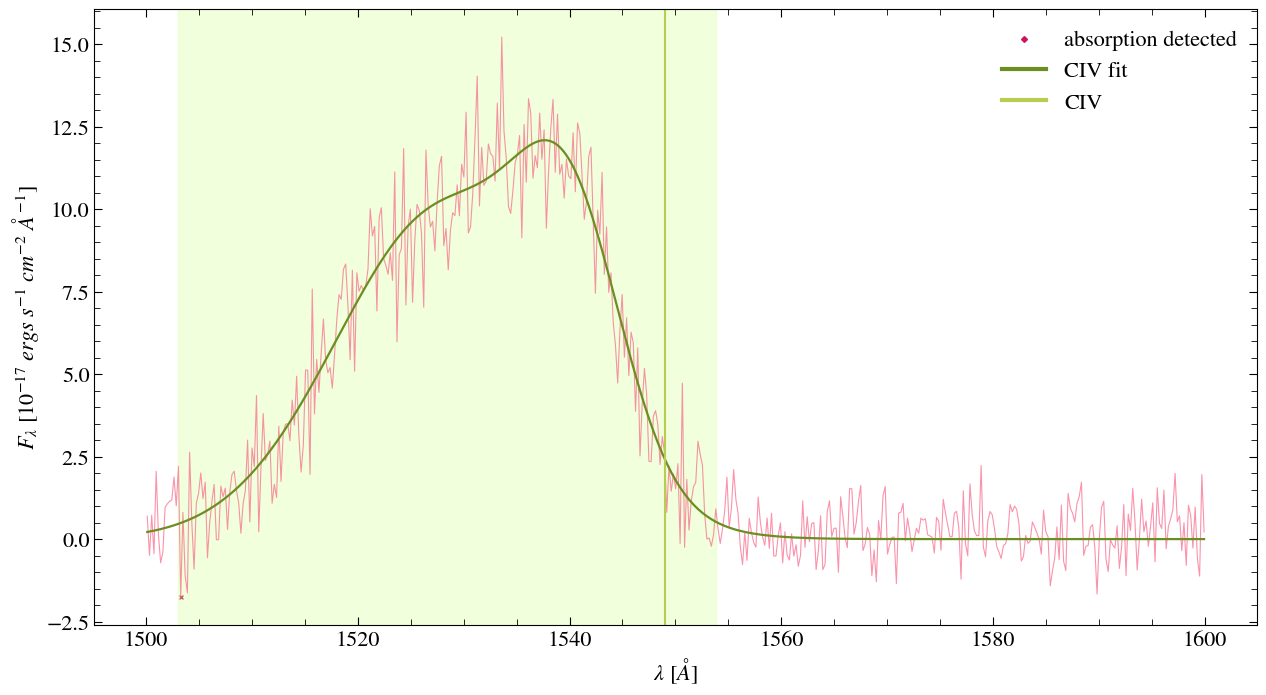

---------------------------------------
---------------------------------------

            SDSS: 093506.96-024137.7

            Lya:	47.167
            NV:		80.236	120.558 (Hamann)
            CIV:	77.194	119.496 (Hamann)
            
            compared to CIV:
            Lya		NV	CIV
            0.61	1.04	1
        


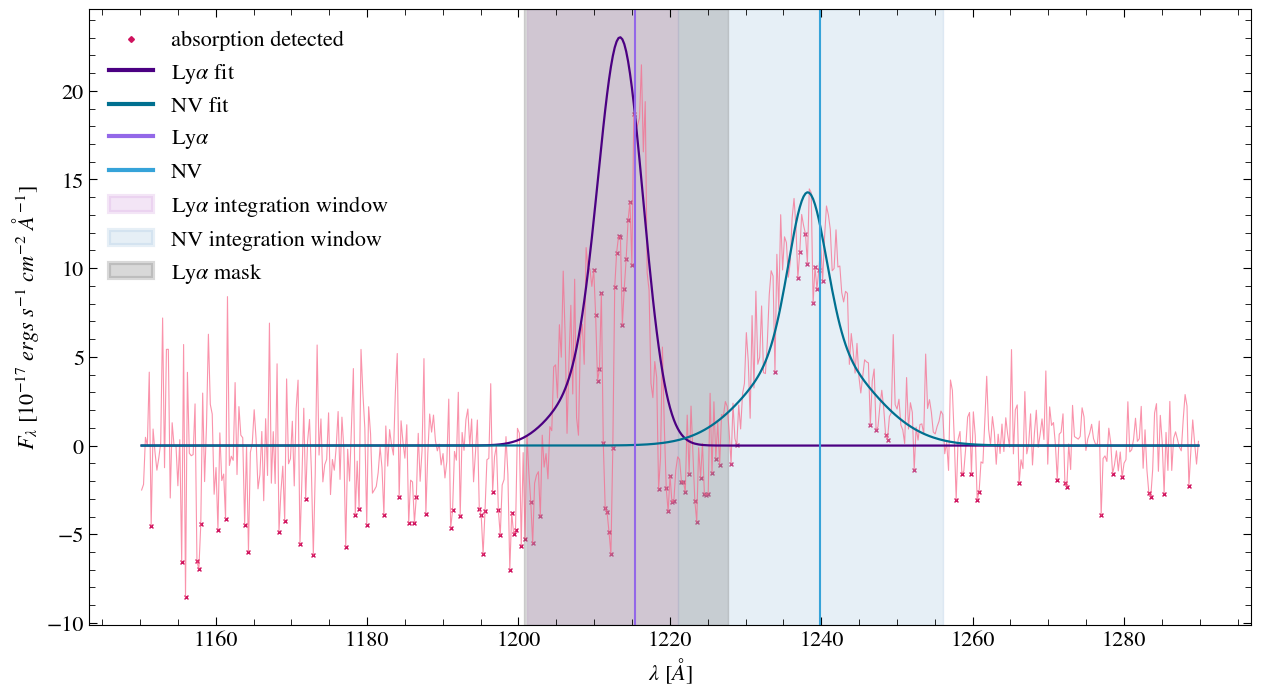

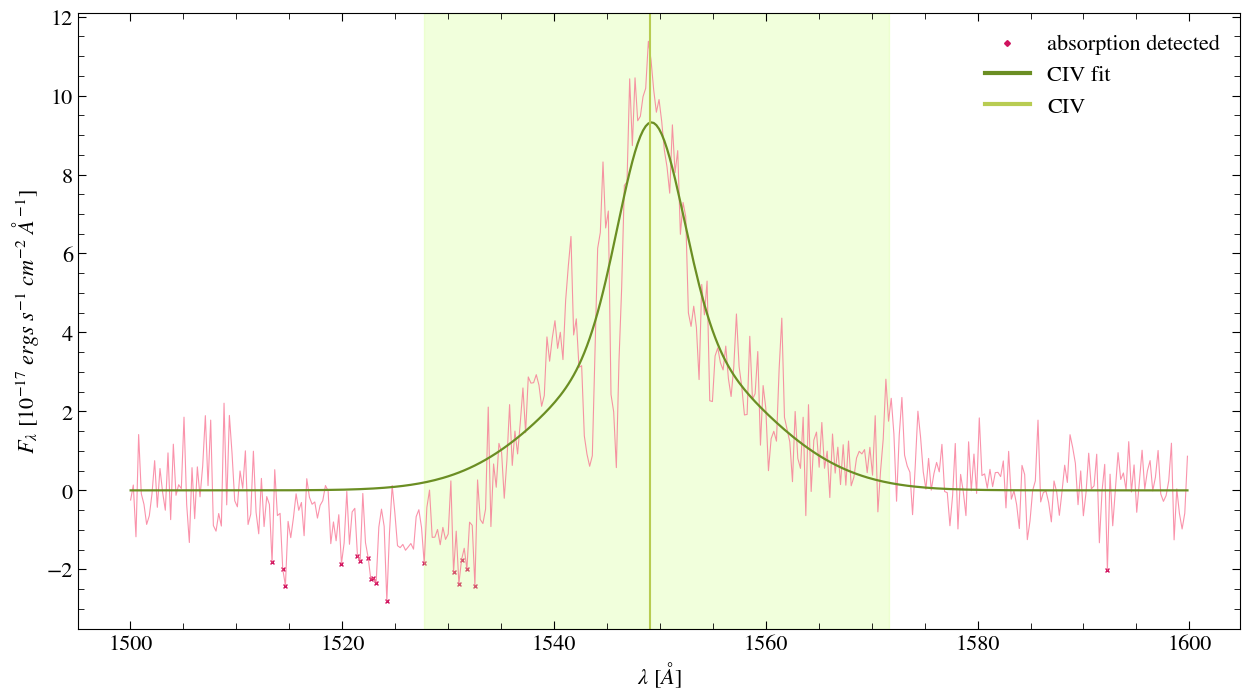

---------------------------------------
---------------------------------------

            SDSS: 232326.17-010033.1

            Lya:	154.667
            NV:		414.435	565.970 (Hamann)
            CIV:	300.010	255.993 (Hamann)
            
            compared to CIV:
            Lya		NV	CIV
            0.52	1.38	1
        


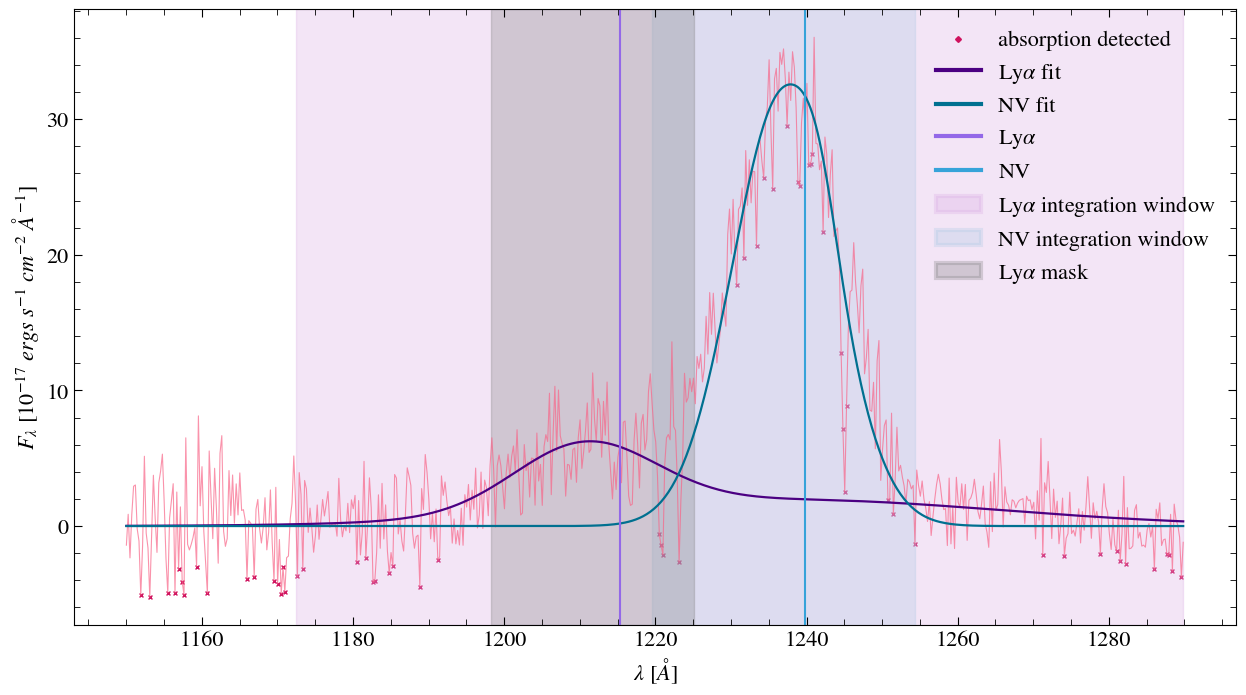

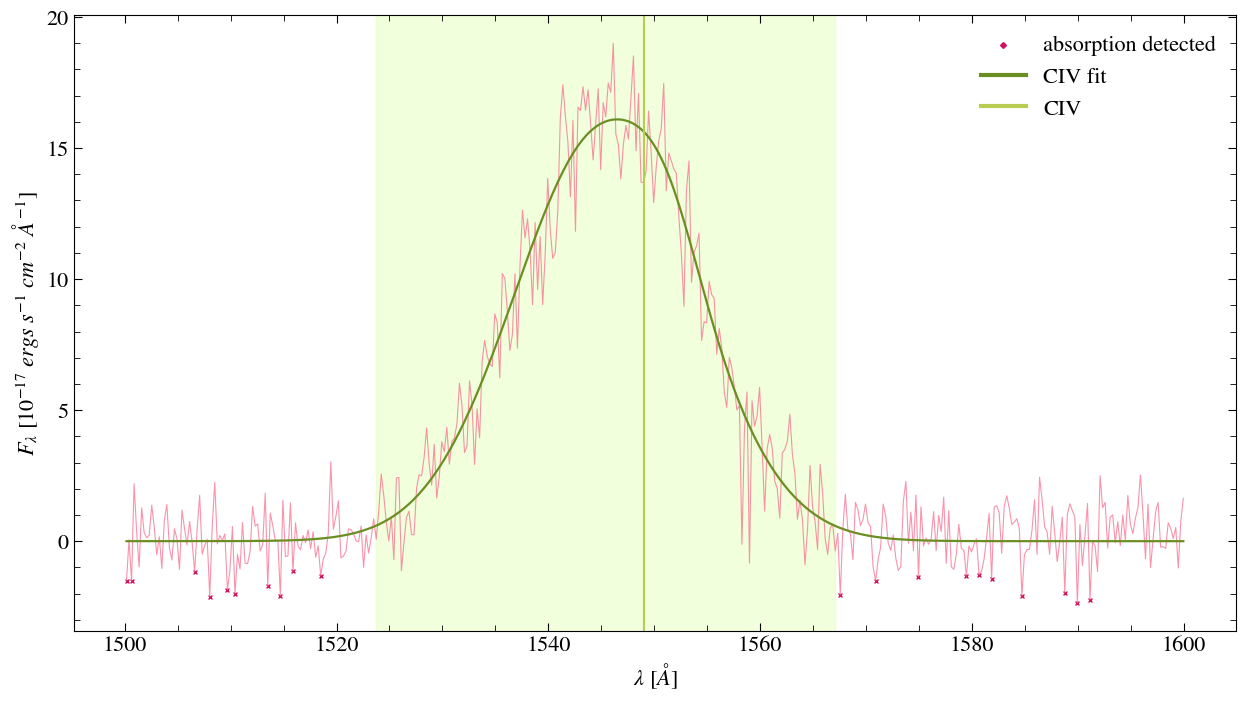

---------------------------------------
---------------------------------------

            SDSS: 103146.53+290324.1

            Lya:	80.880
            NV:		182.547	192.525 (Hamann)
            CIV:	97.910	120.767 (Hamann)
            
            compared to CIV:
            Lya		NV	CIV
            0.83	1.86	1
        


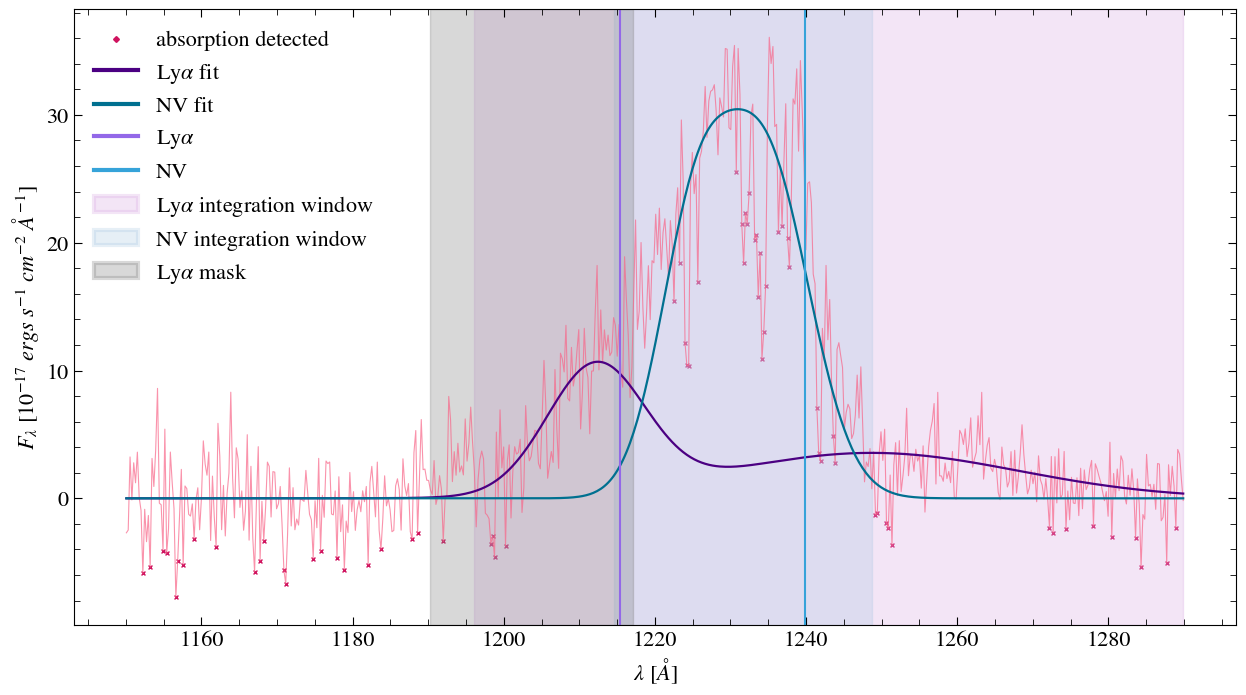

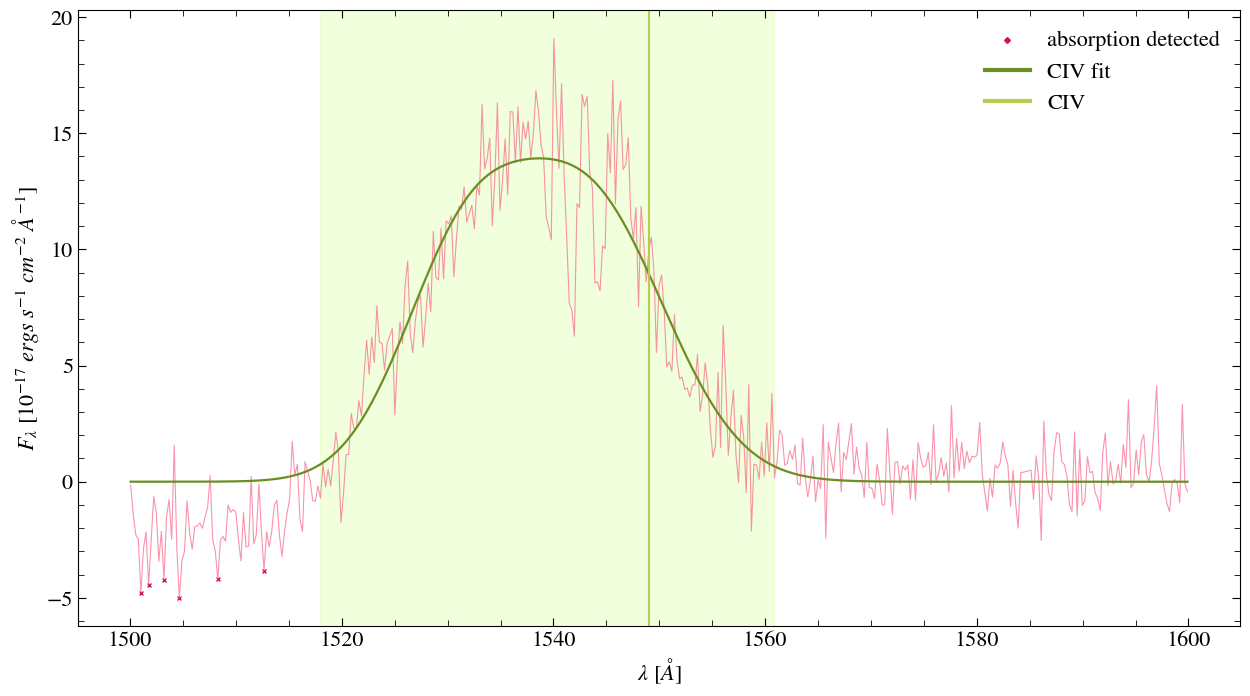

---------------------------------------
---------------------------------------

            SDSS: 165202.64+172852.3

            Lya:	182.532
            NV:		330.981	272.096 (Hamann)
            CIV:	168.142	124.521 (Hamann)
            
            compared to CIV:
            Lya		NV	CIV
            1.09	1.97	1
        


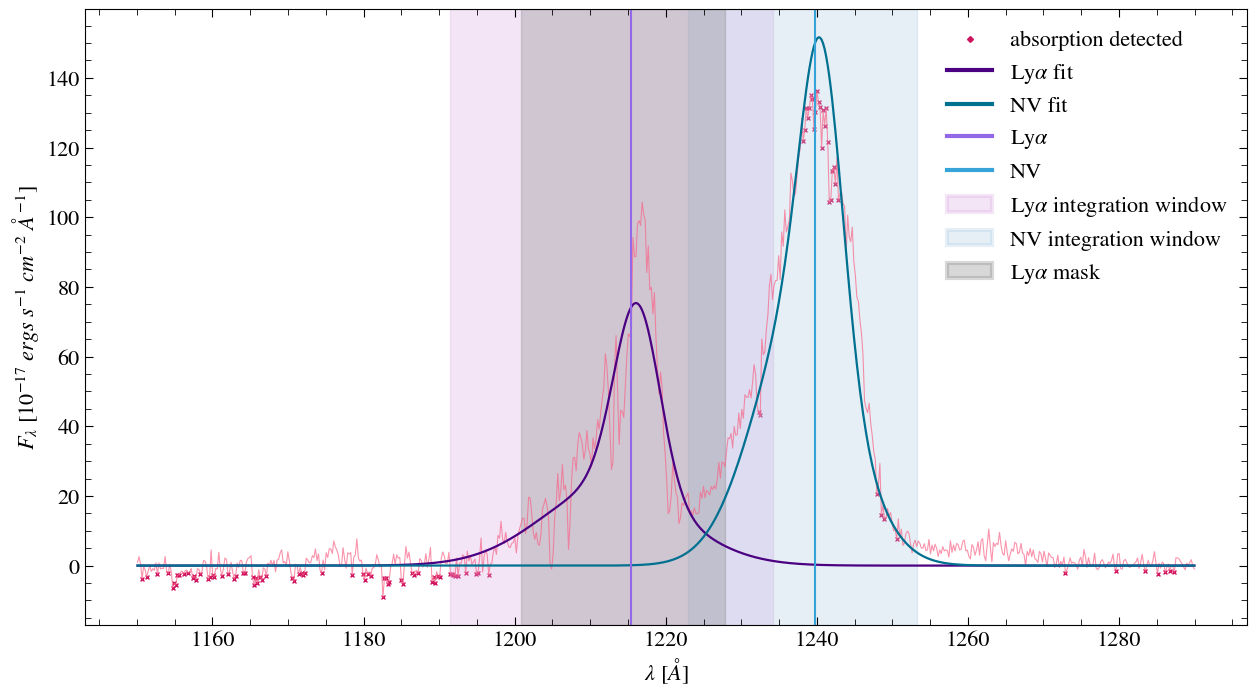

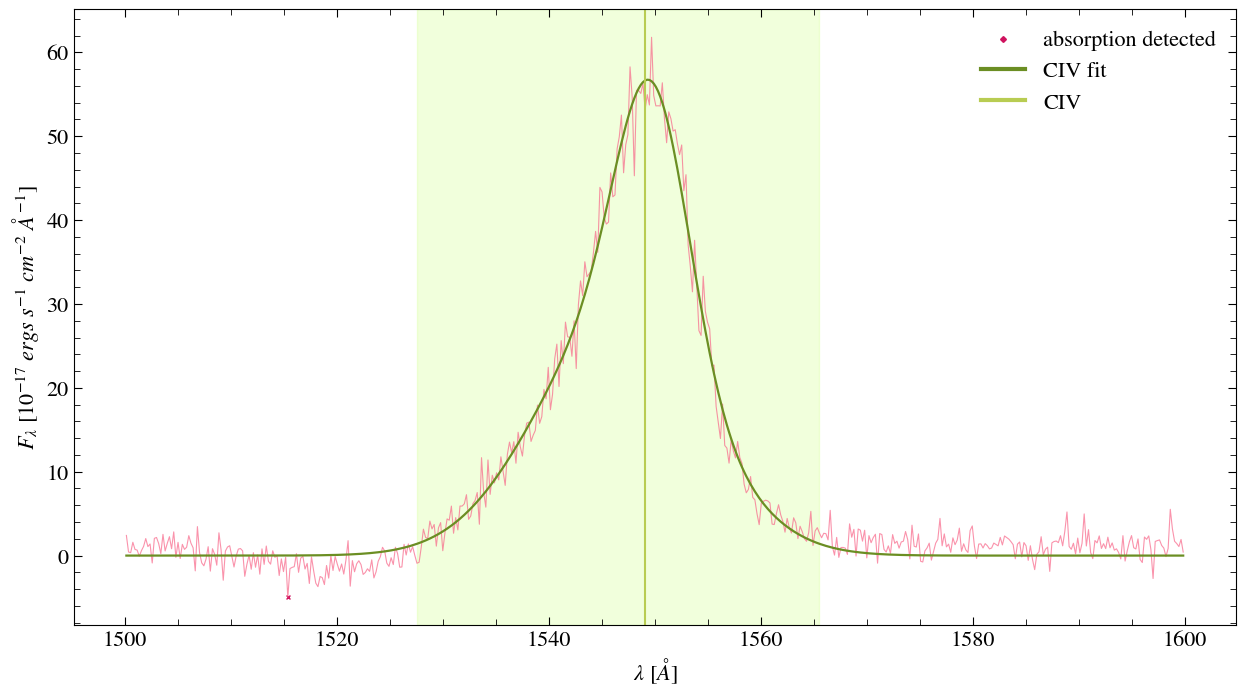

---------------------------------------
---------------------------------------

            SDSS: 122000.68+064045.3

            Lya:	437.186
            NV:		62.832	77.283 (Hamann)
            CIV:	113.327	112.877 (Hamann)
            
            compared to CIV:
            Lya		NV	CIV
            3.86	0.55	1
        


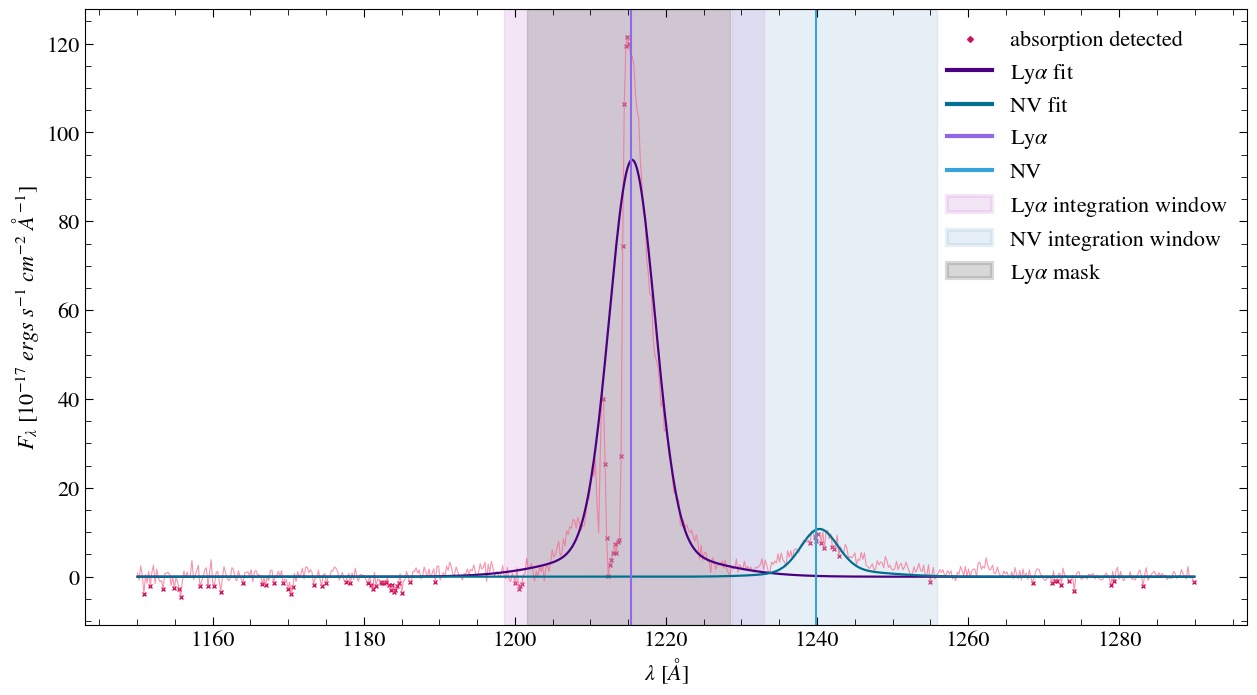

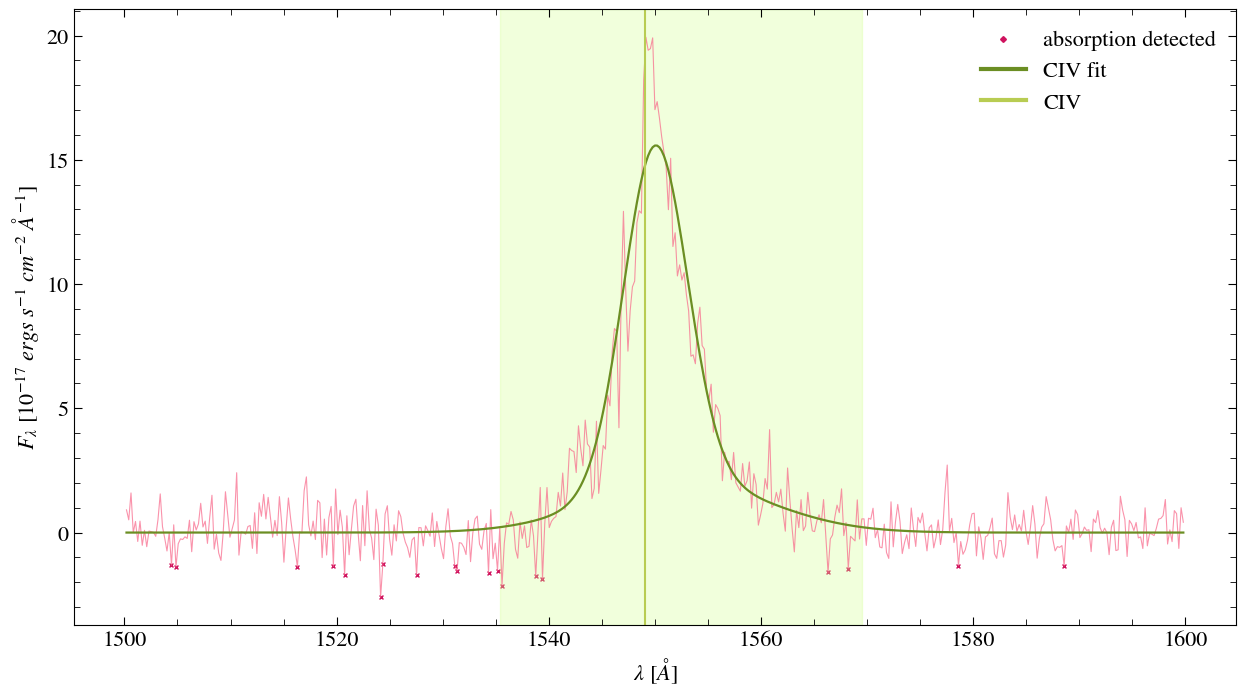

---------------------------------------
---------------------------------------

            SDSS: 121704.70+023417.1

            Lya:	369.833
            NV:		430.007	547.494 (Hamann)
            CIV:	180.036	180.897 (Hamann)
            
            compared to CIV:
            Lya		NV	CIV
            2.05	2.39	1
        


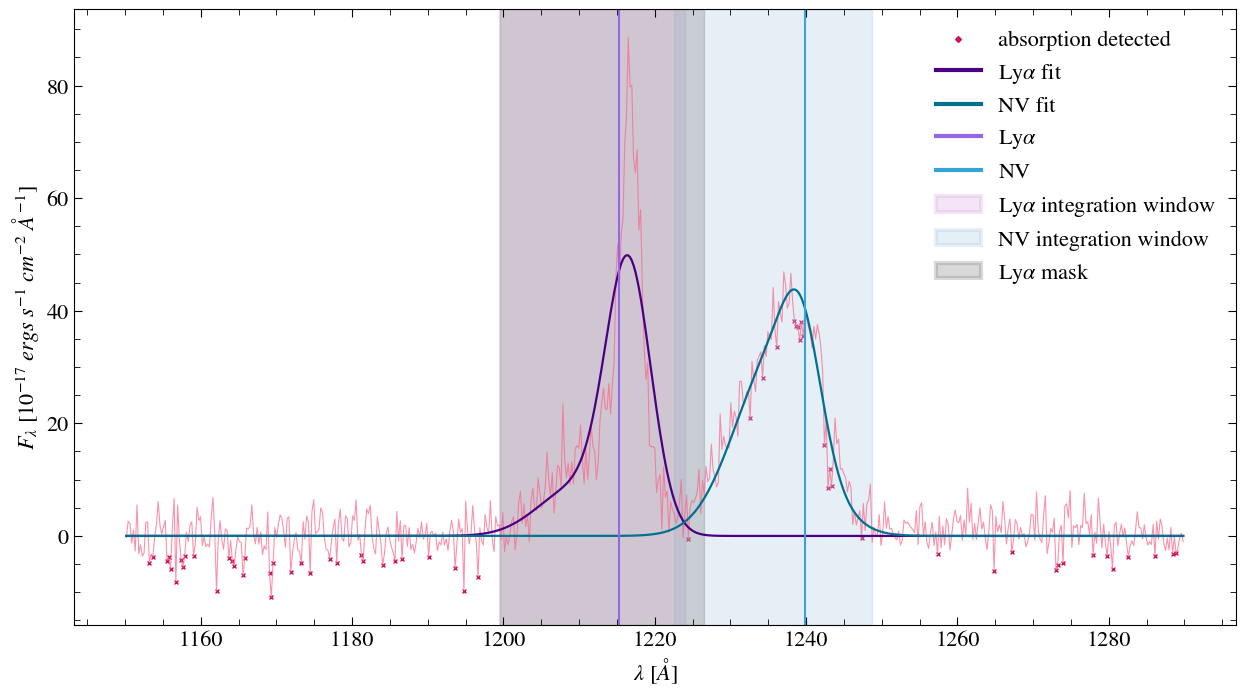

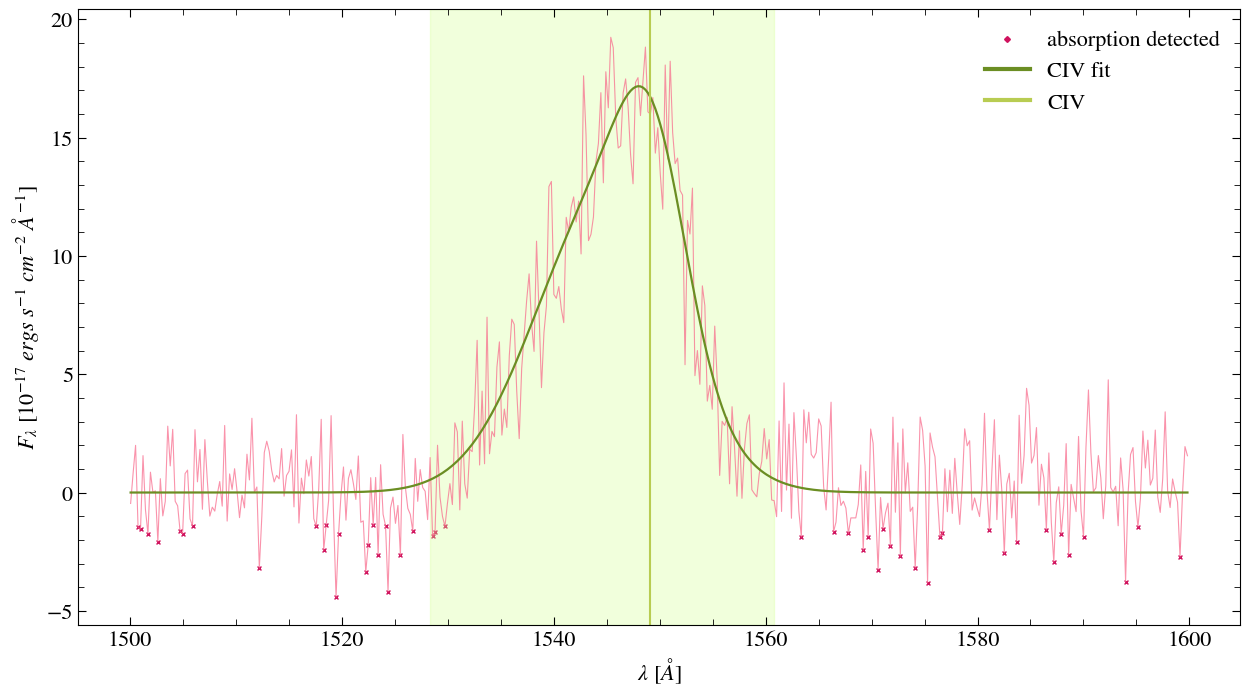

---------------------------------------
---------------------------------------

            SDSS: 131047.78+322518.3

            Lya:	373.474
            NV:		479.546	527.673 (Hamann)
            CIV:	213.700	226.394 (Hamann)
            
            compared to CIV:
            Lya		NV	CIV
            1.75	2.24	1
        


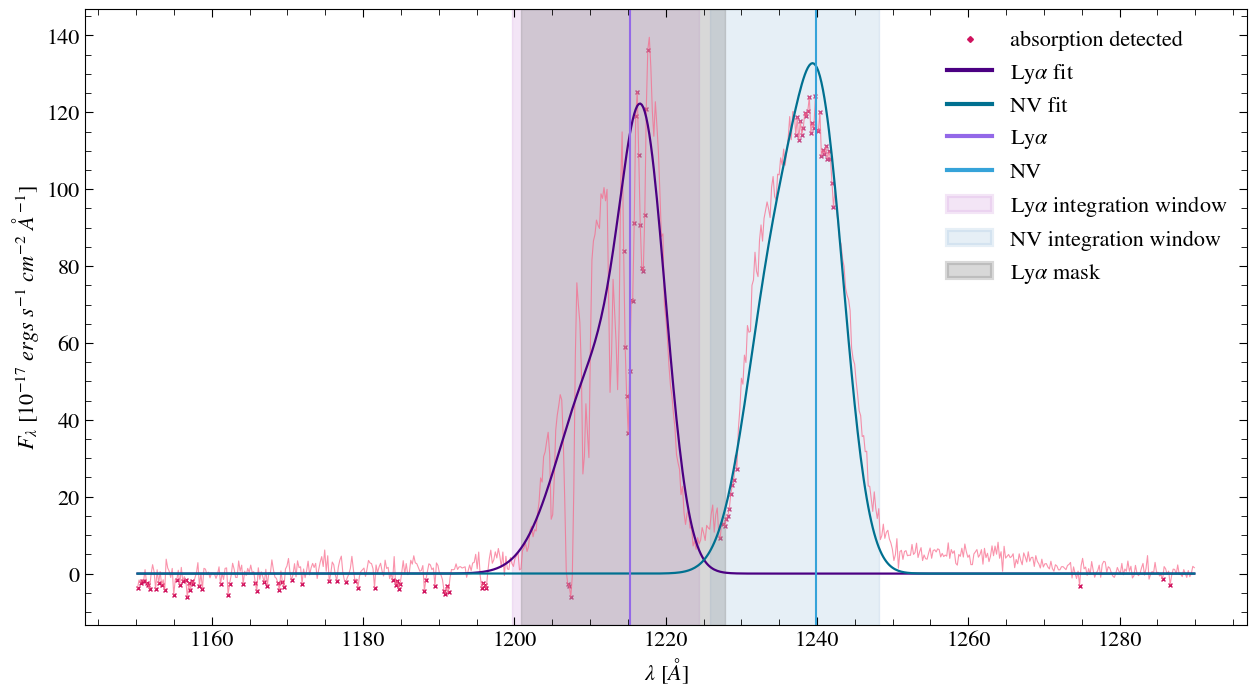

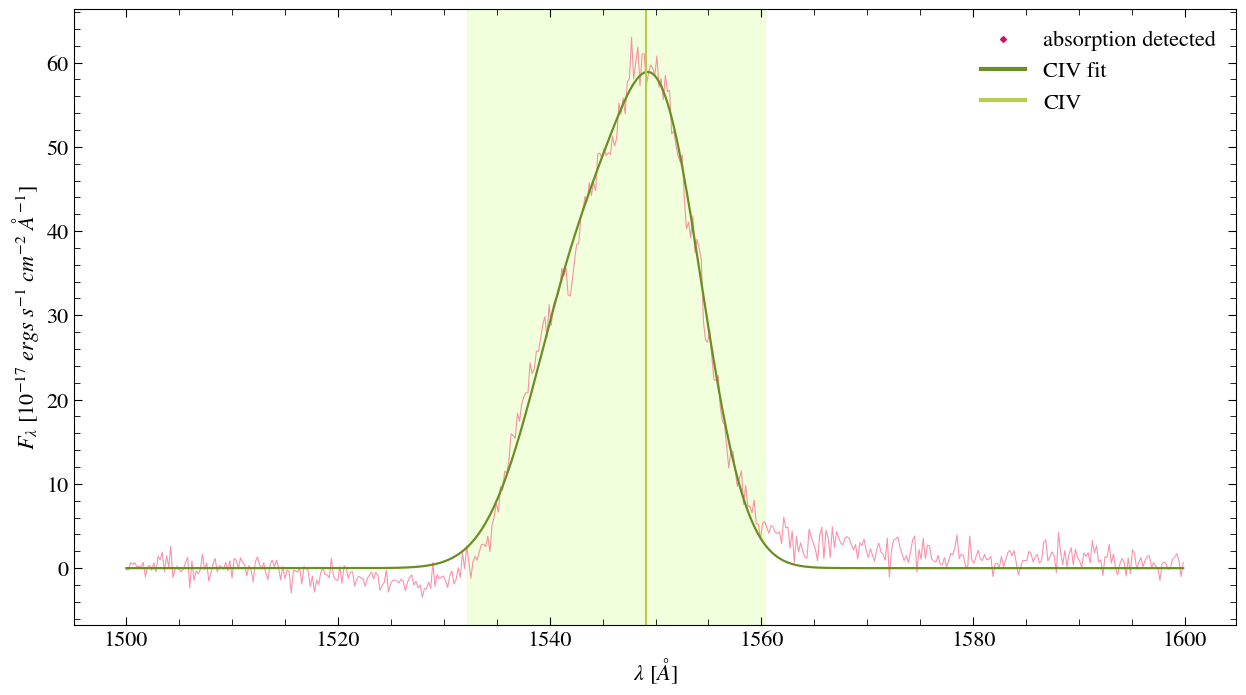

---------------------------------------
---------------------------------------
Too little valid pixels to measure line.

            SDSS: 221524.00-005643.8

            Lya:	453.332
            NV:		nan	117.304 (Hamann)
            CIV:	193.825	153.336 (Hamann)
            
            compared to CIV:
            Lya		NV	CIV
            2.34	nan	1
        


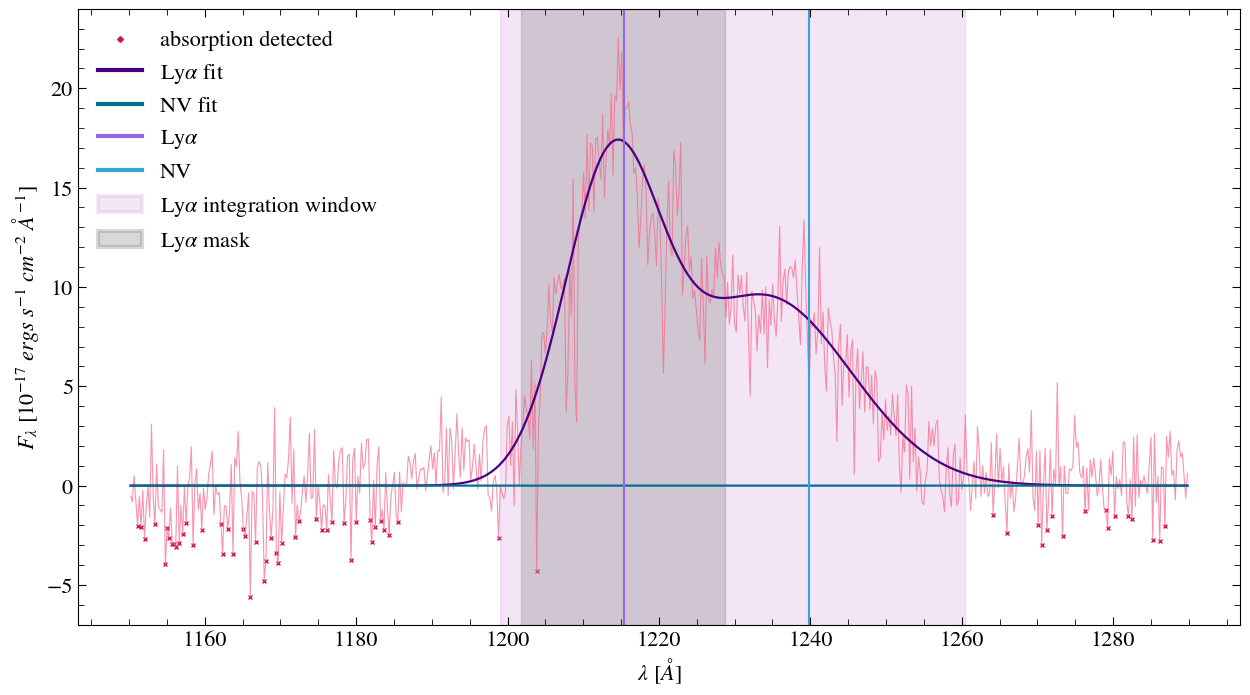

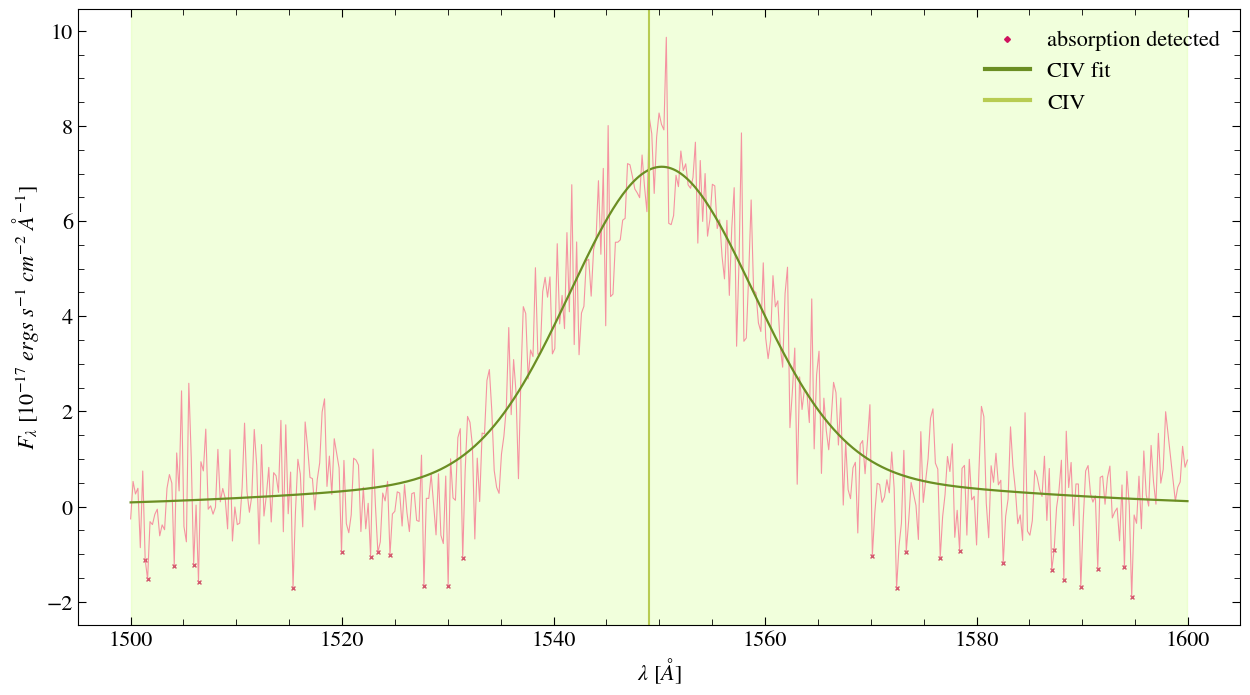

---------------------------------------
---------------------------------------

            SDSS: 134450.51+140139.2

            Lya:	69.451
            NV:		236.898	385.165 (Hamann)
            CIV:	121.342	132.410 (Hamann)
            
            compared to CIV:
            Lya		NV	CIV
            0.57	1.95	1
        


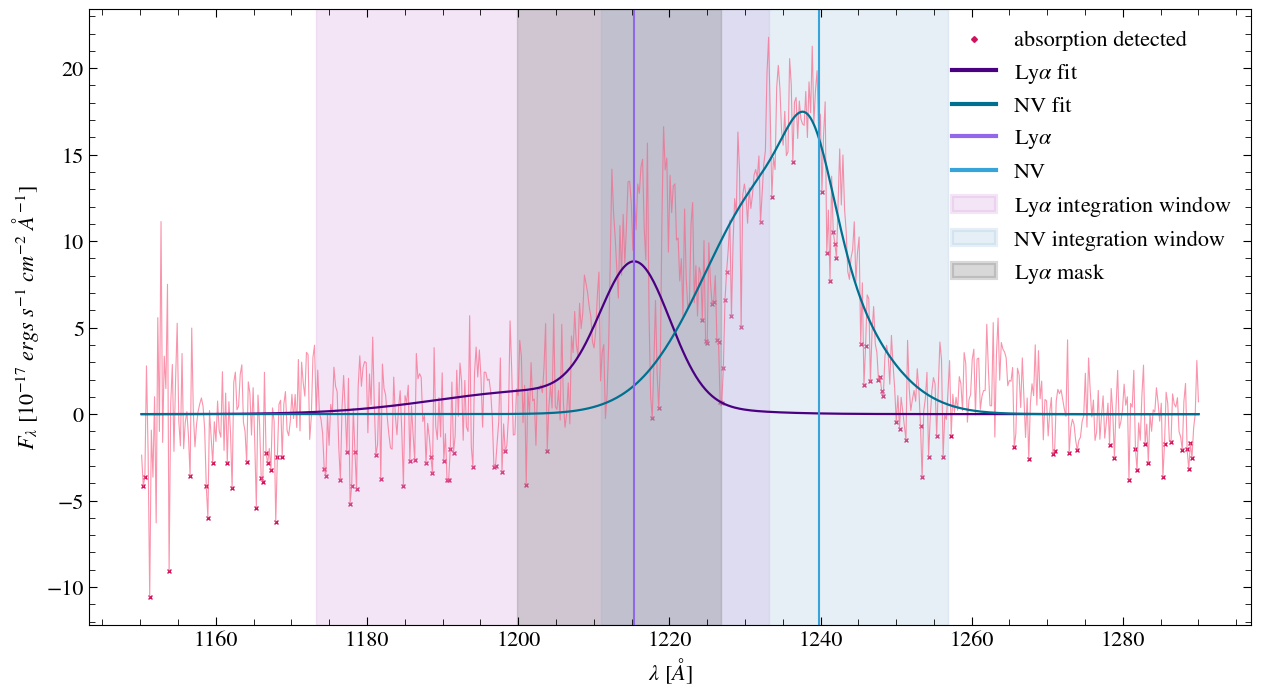

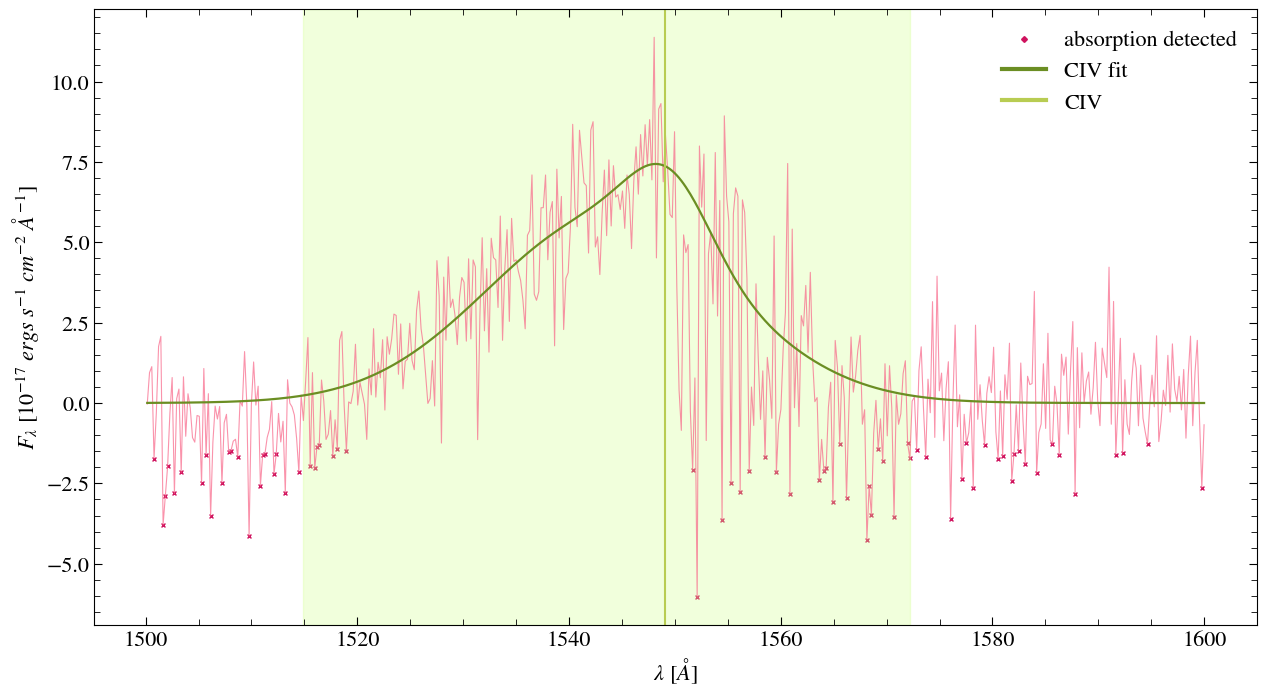

---------------------------------------
---------------------------------------

            SDSS: 153107.14+105825.8

            Lya:	68.577
            NV:		170.698	153.346 (Hamann)
            CIV:	145.138	151.904 (Hamann)
            
            compared to CIV:
            Lya		NV	CIV
            0.47	1.18	1
        


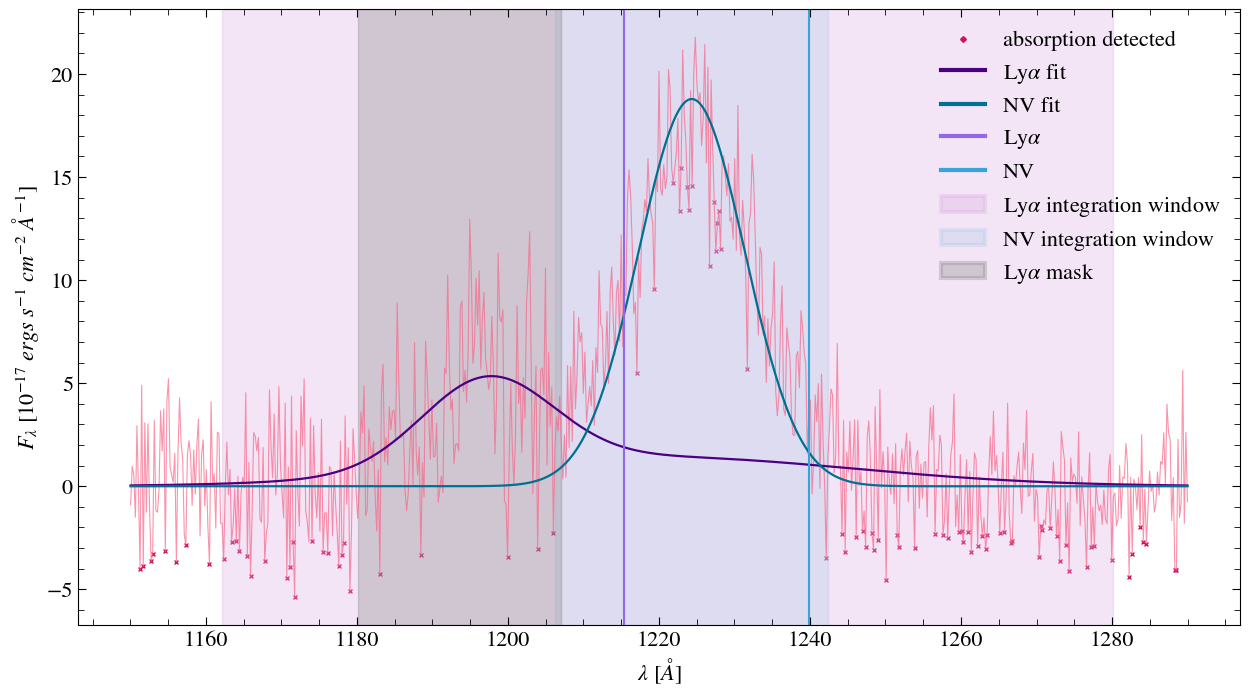

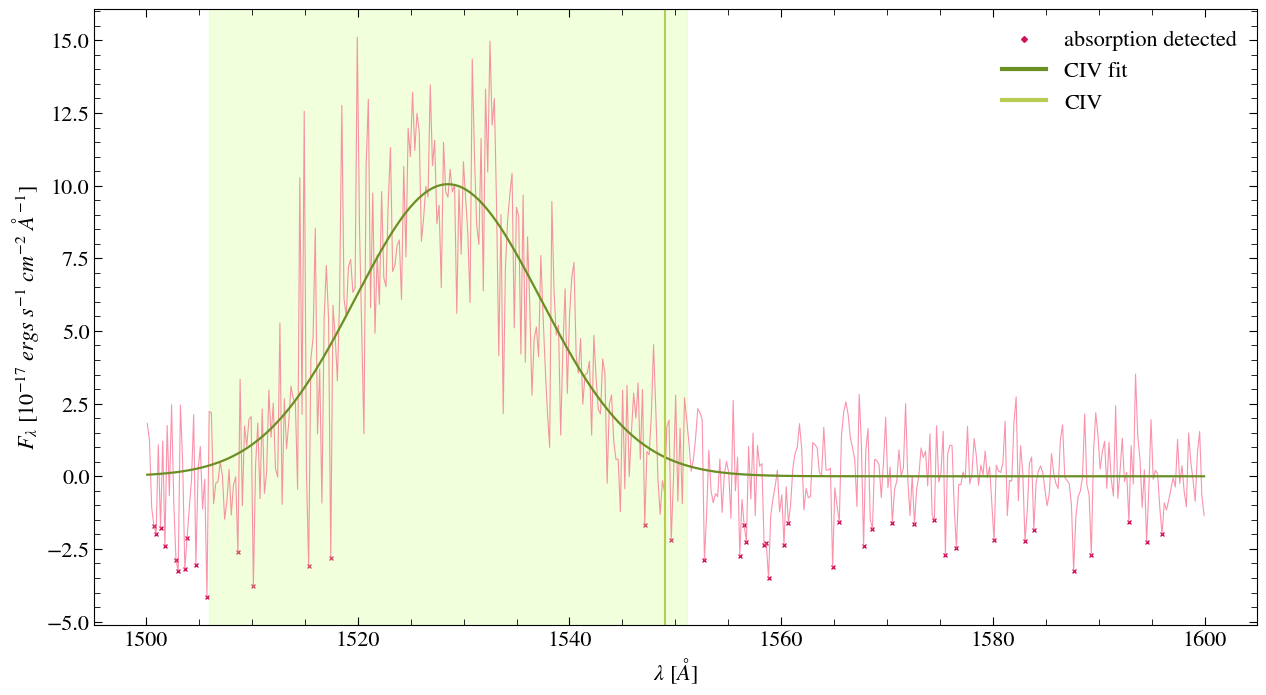

---------------------------------------
---------------------------------------

            SDSS: 104718.35+484433.8

            Lya:	767.900
            NV:		114.974	63.864 (Hamann)
            CIV:	147.943	158.030 (Hamann)
            
            compared to CIV:
            Lya		NV	CIV
            5.19	0.78	1
        


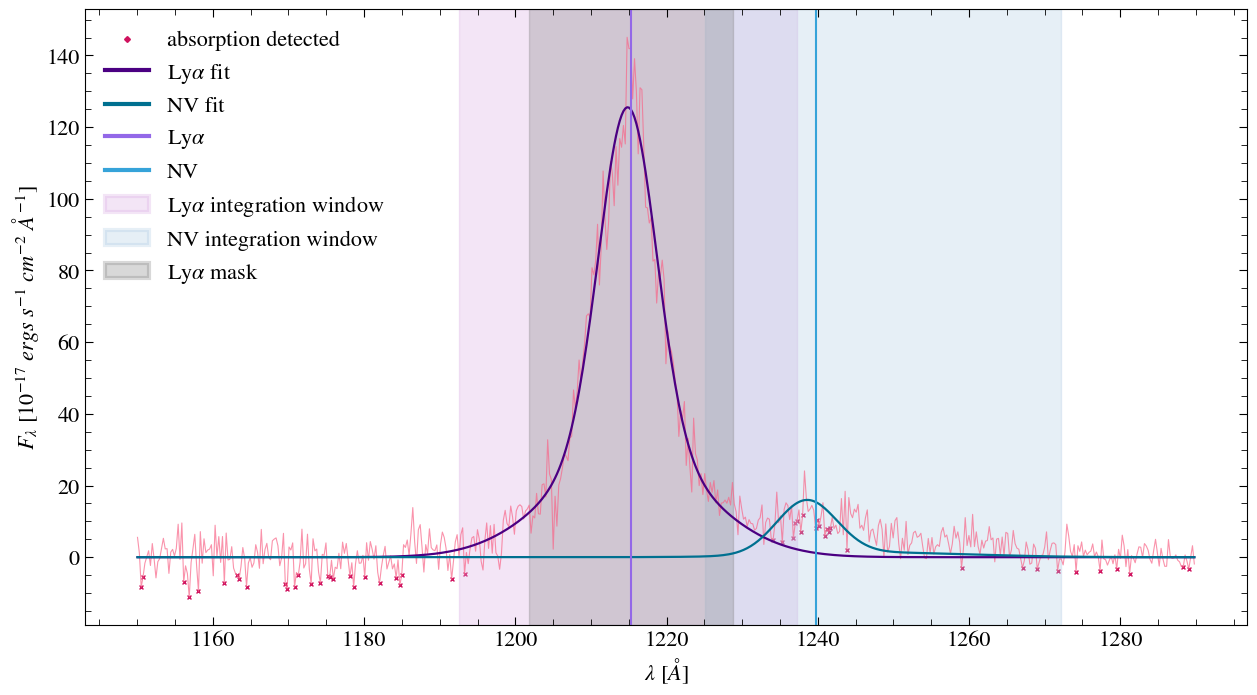

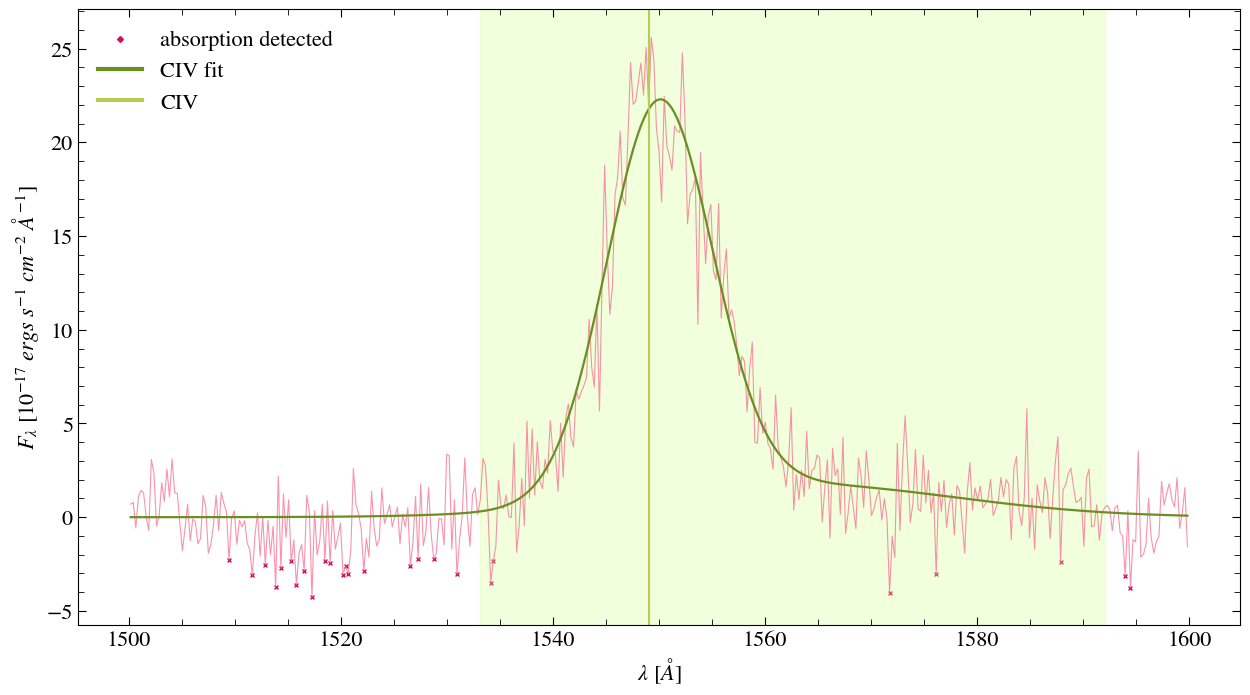

---------------------------------------
---------------------------------------

            SDSS: 020932.15+312202.7

            Lya:	381.185
            NV:		132.468	103.793 (Hamann)
            CIV:	122.106	107.677 (Hamann)
            
            compared to CIV:
            Lya		NV	CIV
            3.12	1.08	1
        


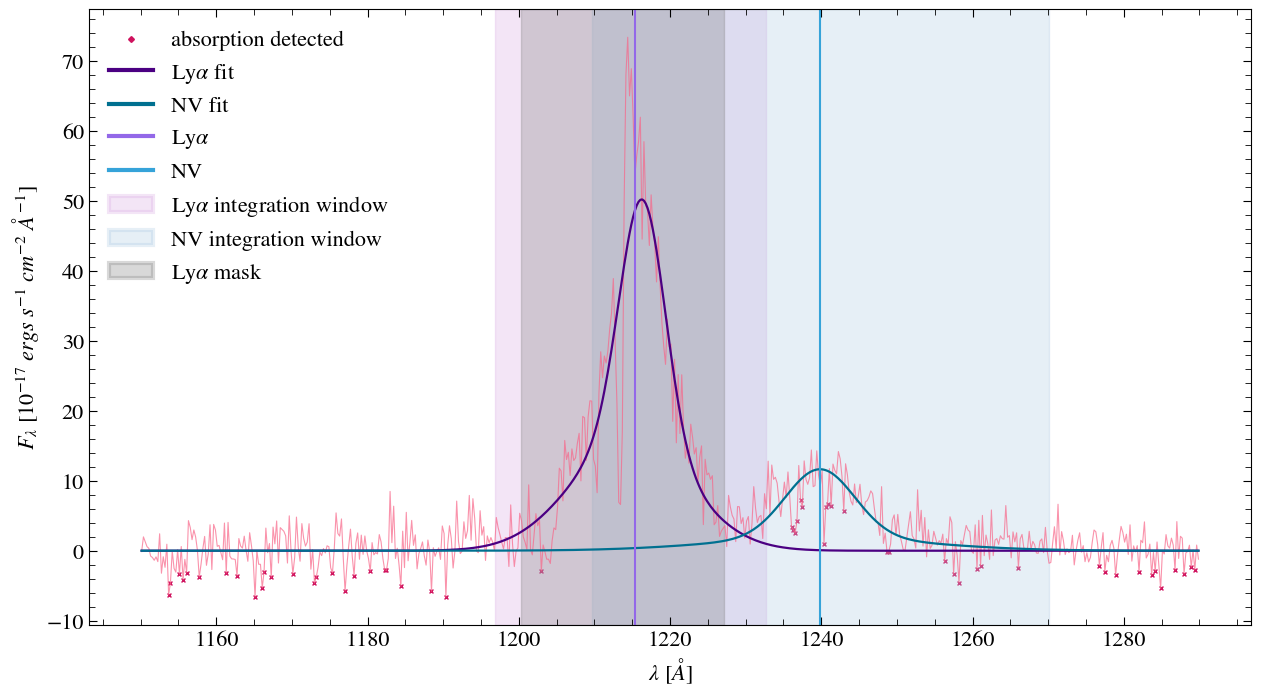

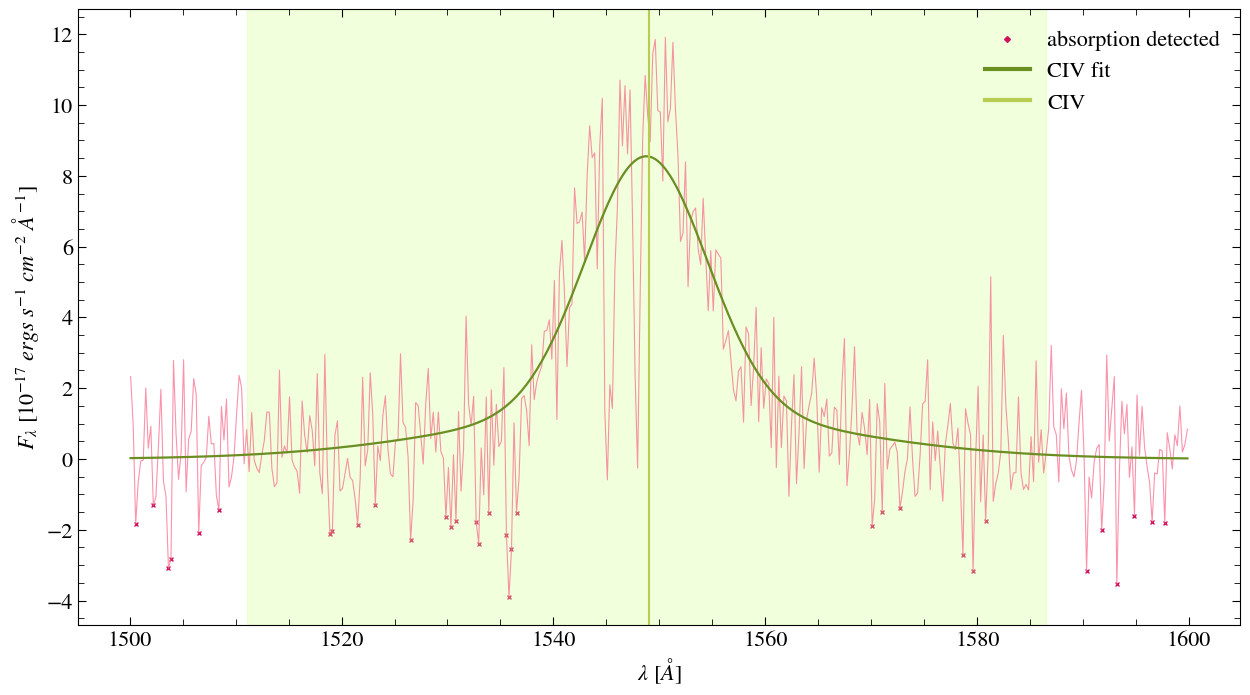

---------------------------------------
---------------------------------------

            SDSS: 082653.42+054247.3

            Lya:	309.802
            NV:		243.333	324.365 (Hamann)
            CIV:	191.204	204.619 (Hamann)
            
            compared to CIV:
            Lya		NV	CIV
            1.62	1.27	1
        


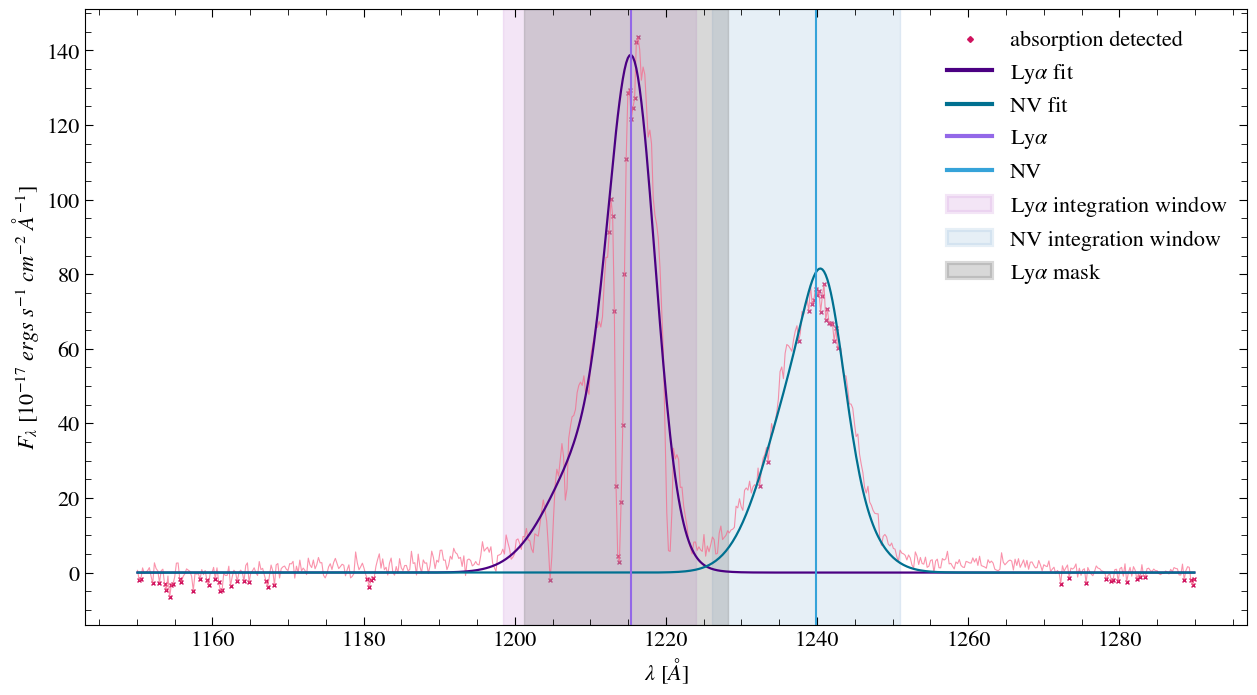

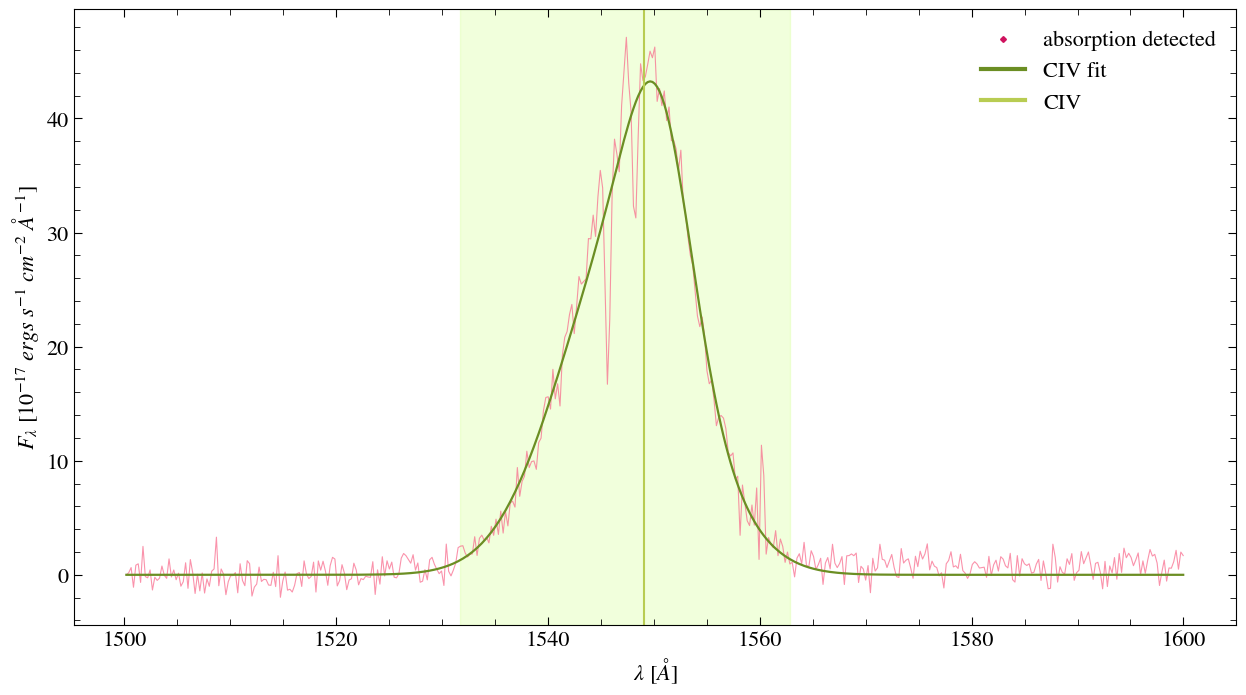

---------------------------------------
---------------------------------------

            SDSS: 232828.47+044346.8

            Lya:	1146.174
            NV:		94.516	122.280 (Hamann)
            CIV:	328.615	358.596 (Hamann)
            
            compared to CIV:
            Lya		NV	CIV
            3.49	0.29	1
        


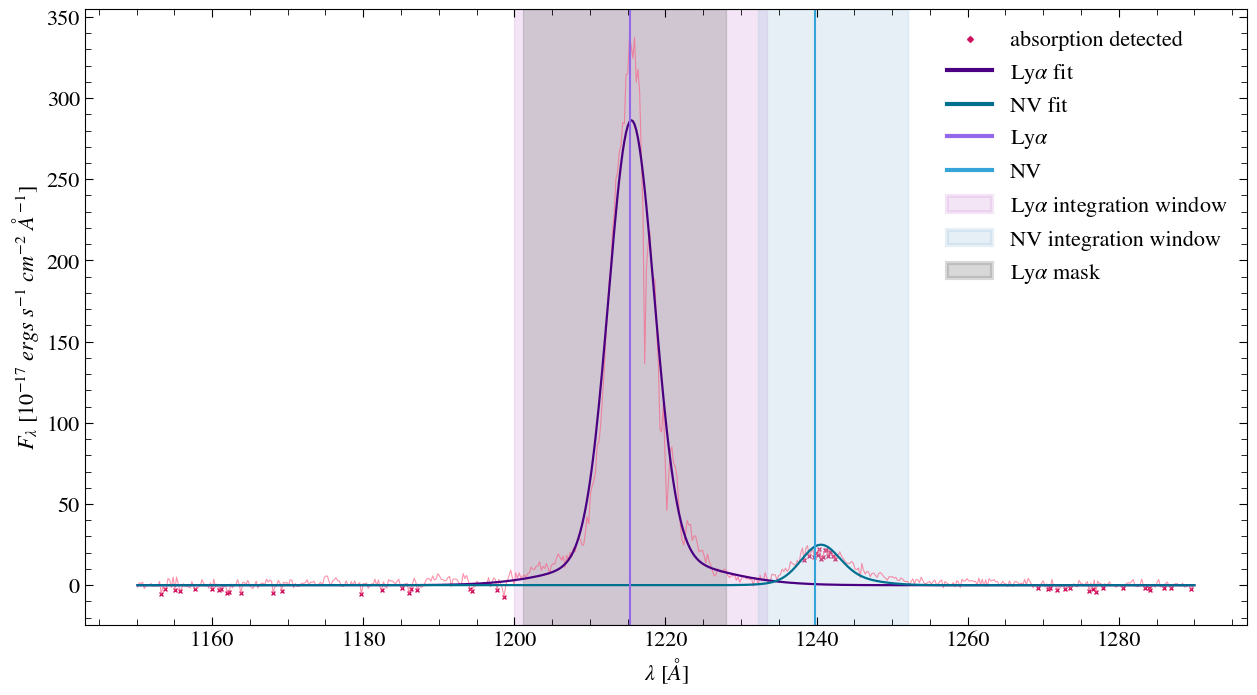

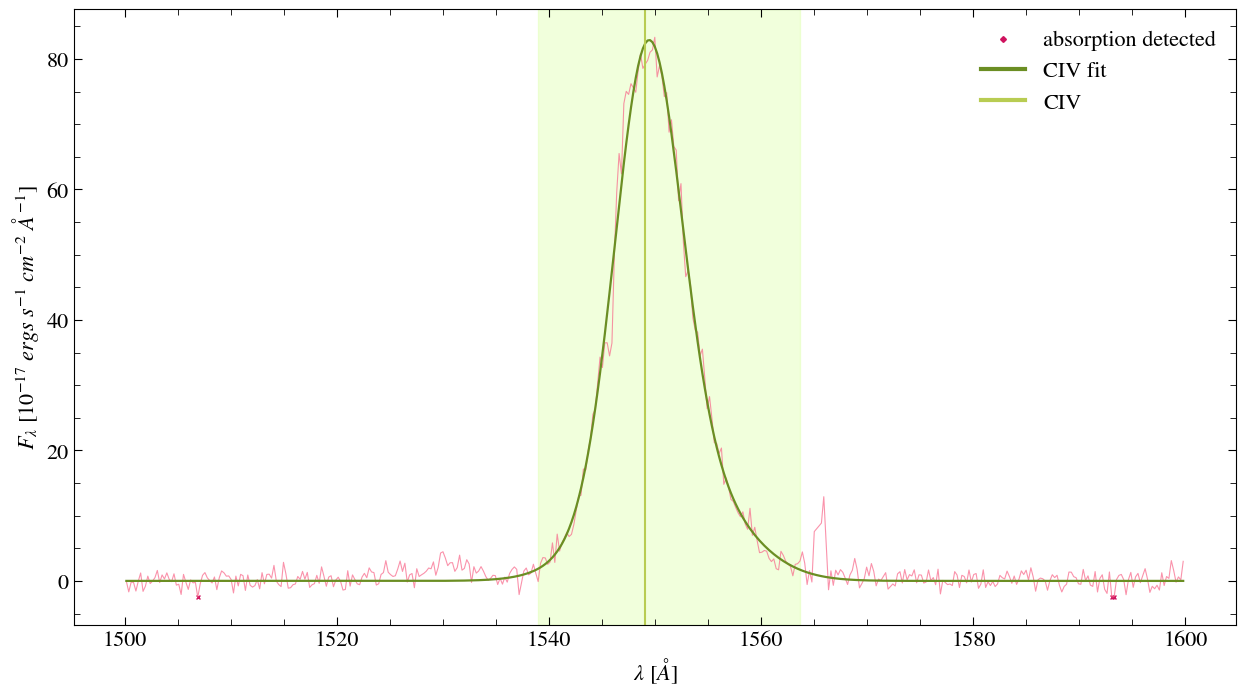

---------------------------------------
---------------------------------------

            SDSS: 154831.92+311951.4

            Lya:	142.165
            NV:		227.091	255.020 (Hamann)
            CIV:	112.432	127.184 (Hamann)
            
            compared to CIV:
            Lya		NV	CIV
            1.26	2.02	1
        


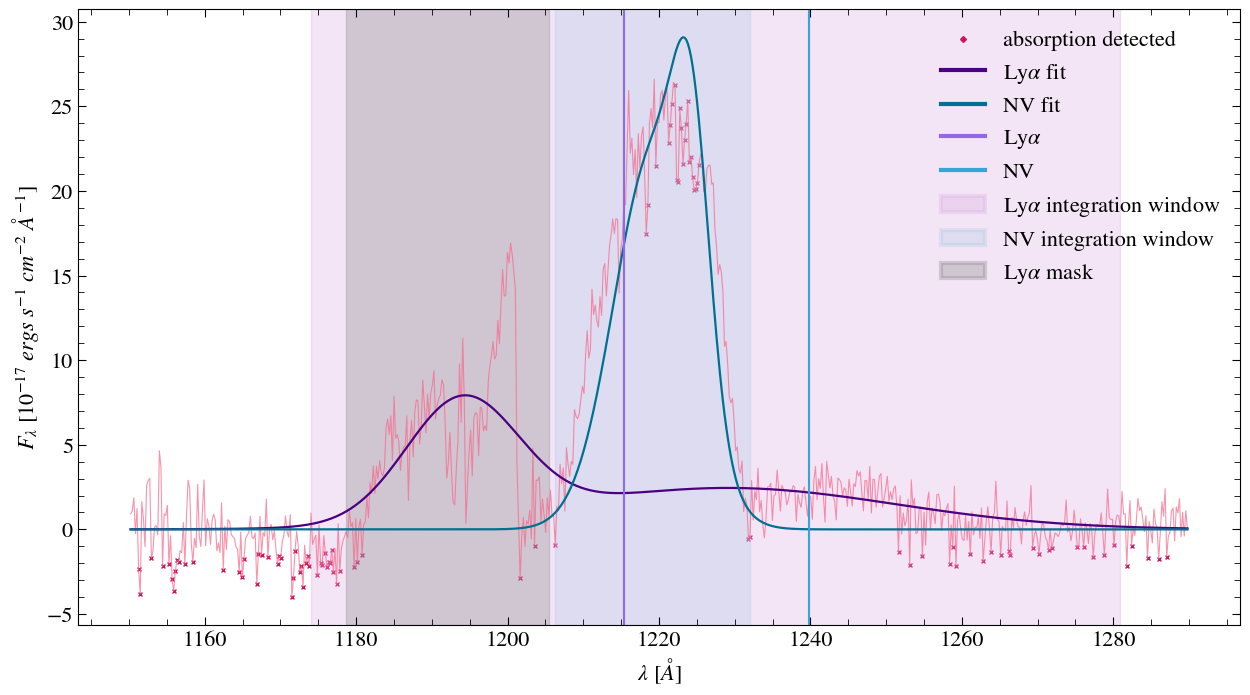

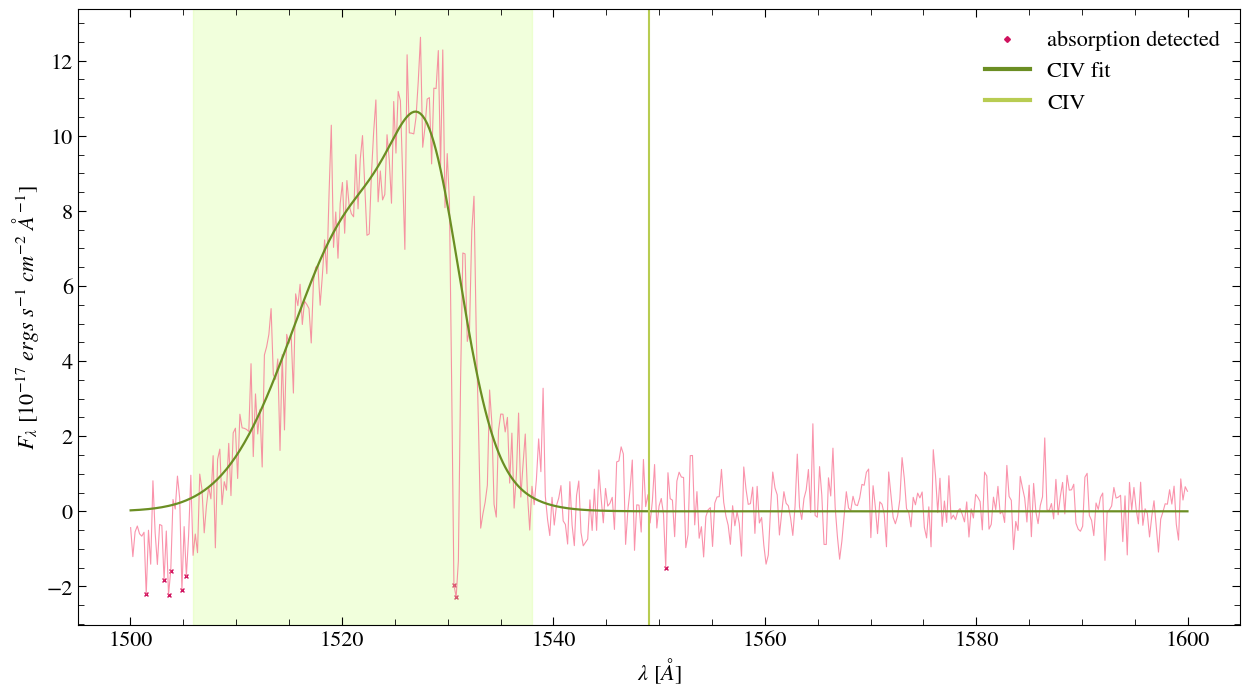

---------------------------------------
---------------------------------------

            SDSS: 080547.66+454159.0

            Lya:	197.413
            NV:		184.864	140.262 (Hamann)
            CIV:	136.011	108.690 (Hamann)
            
            compared to CIV:
            Lya		NV	CIV
            1.45	1.36	1
        


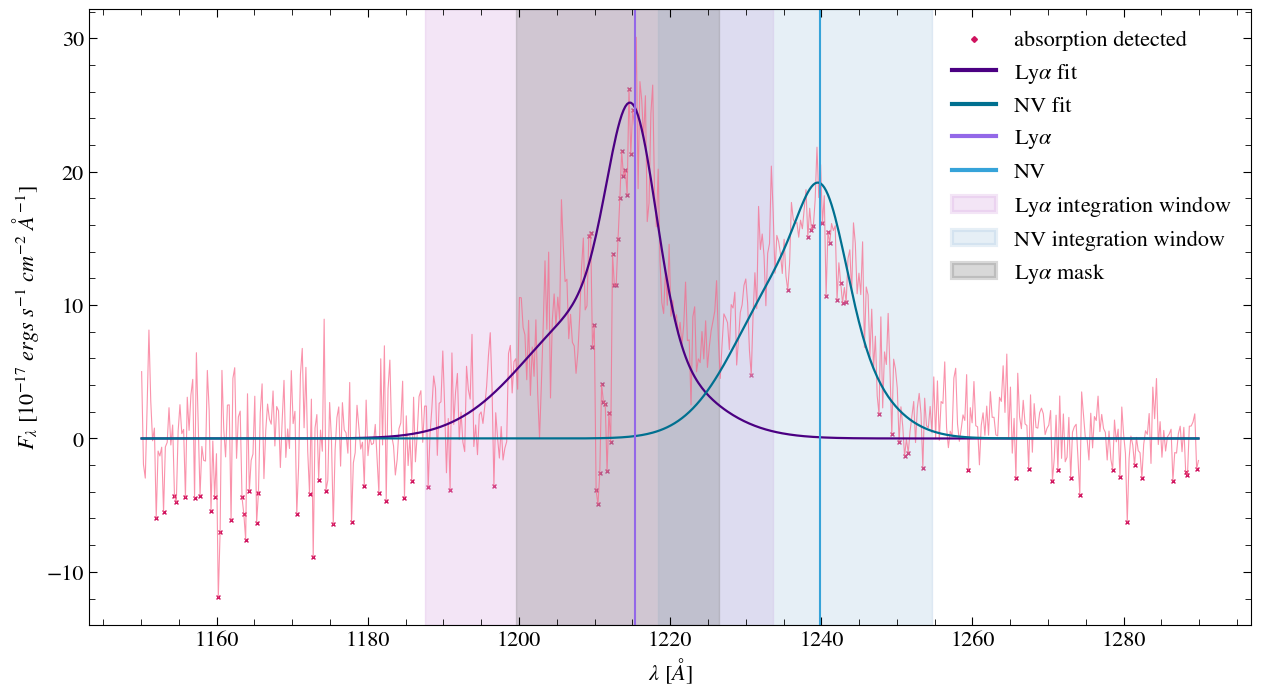

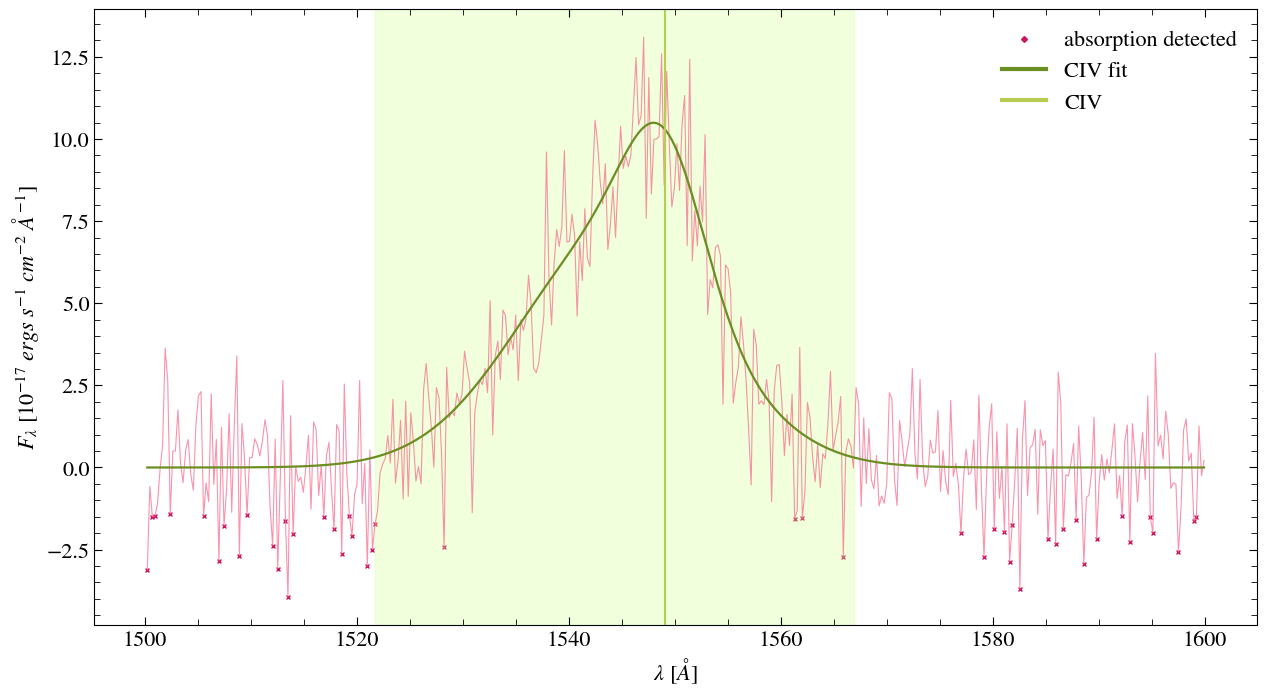

---------------------------------------
---------------------------------------

            SDSS: 014111.13-031852.5

            Lya:	218.045
            NV:		128.556	157.860 (Hamann)
            CIV:	93.643	101.008 (Hamann)
            
            compared to CIV:
            Lya		NV	CIV
            2.33	1.37	1
        


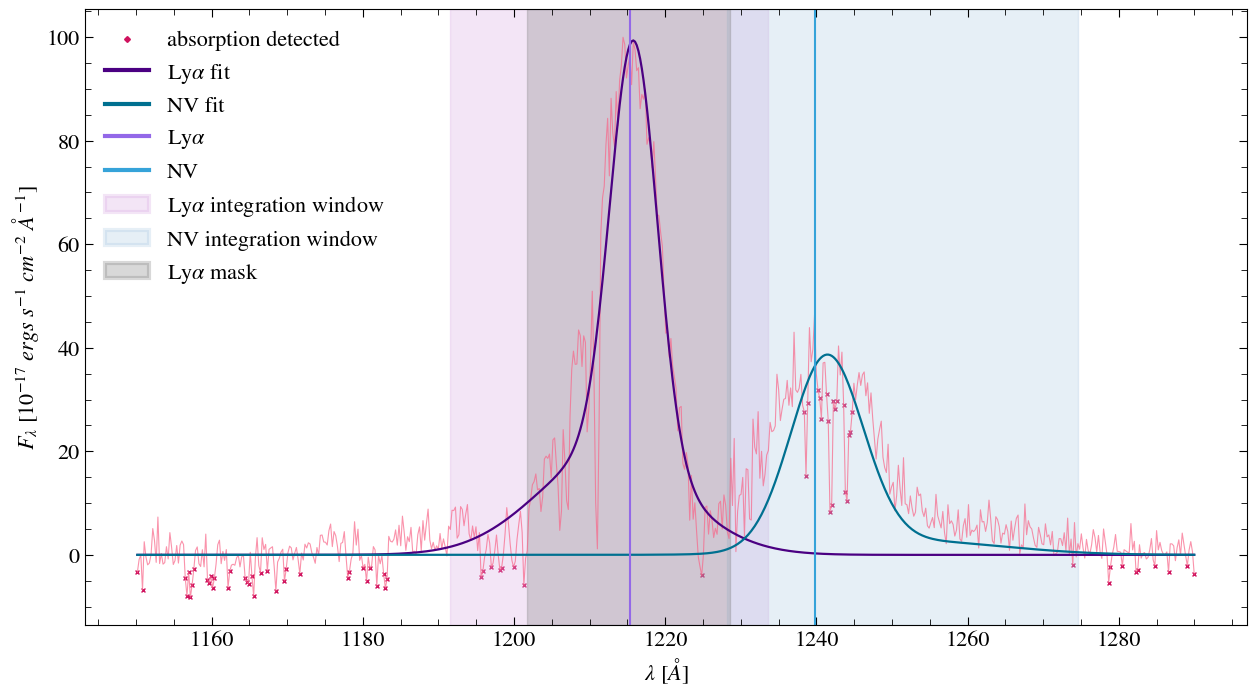

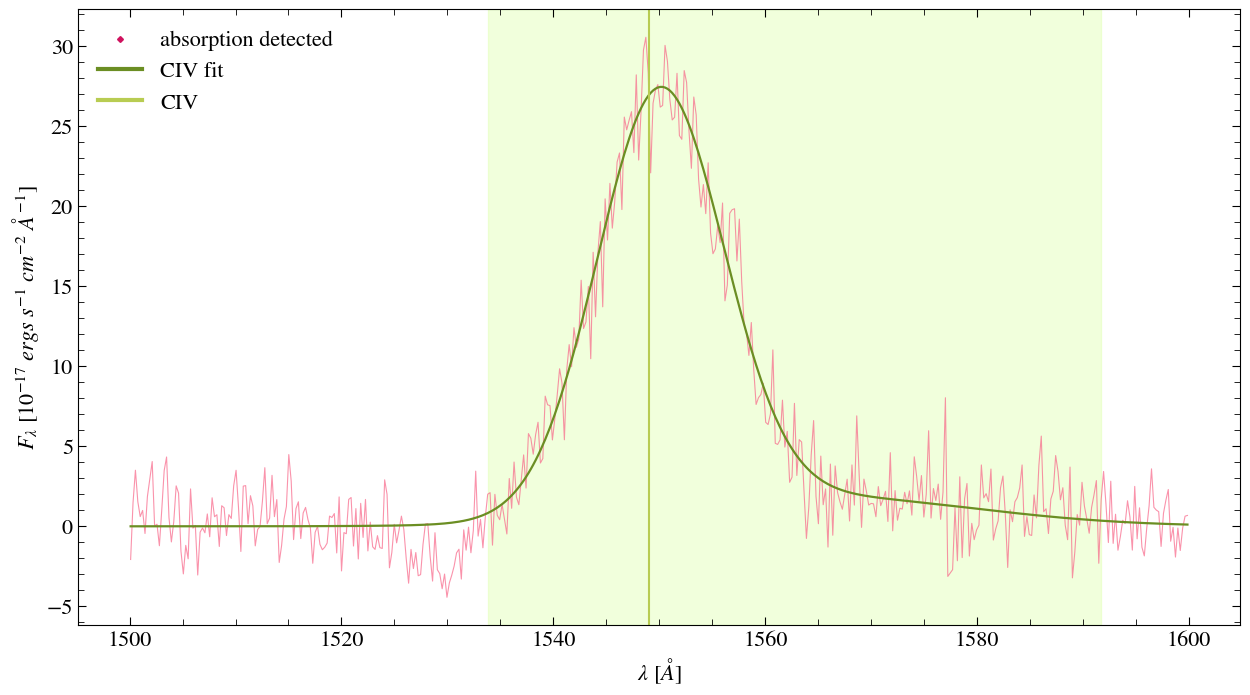

---------------------------------------
---------------------------------------

            SDSS: 000746.19+122223.9

            Lya:	727.203
            NV:		45.680	64.602 (Hamann)
            CIV:	232.652	219.634 (Hamann)
            
            compared to CIV:
            Lya		NV	CIV
            3.13	0.20	1
        


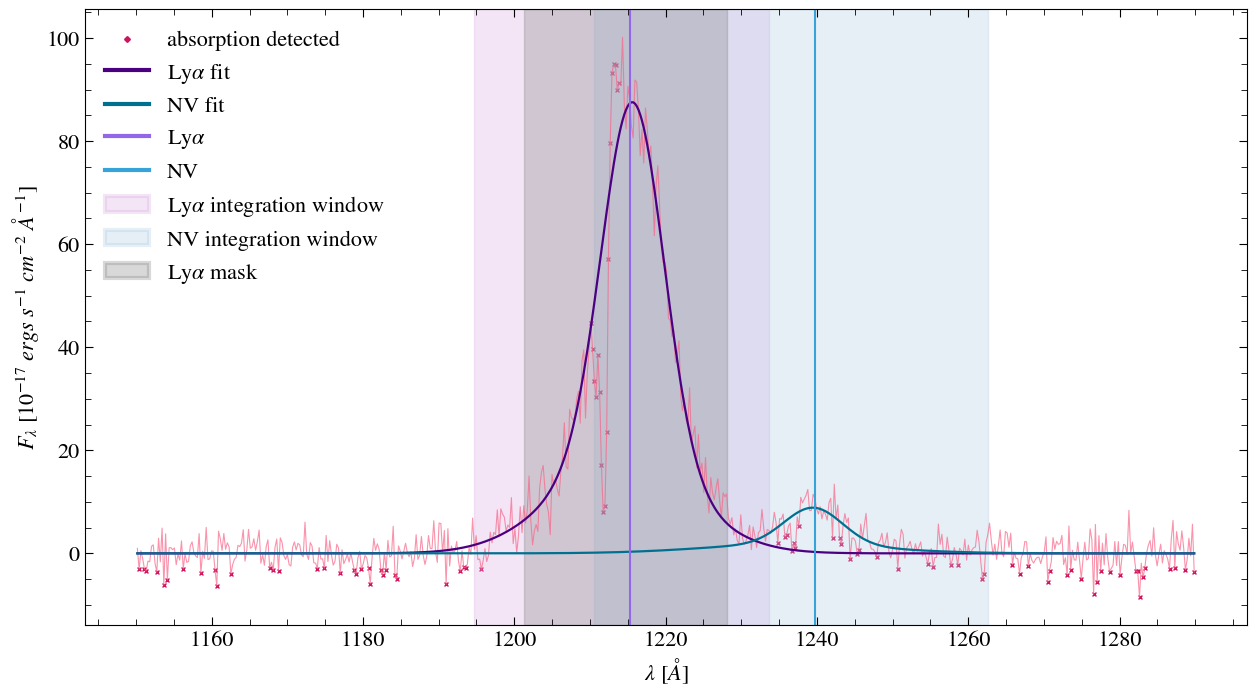

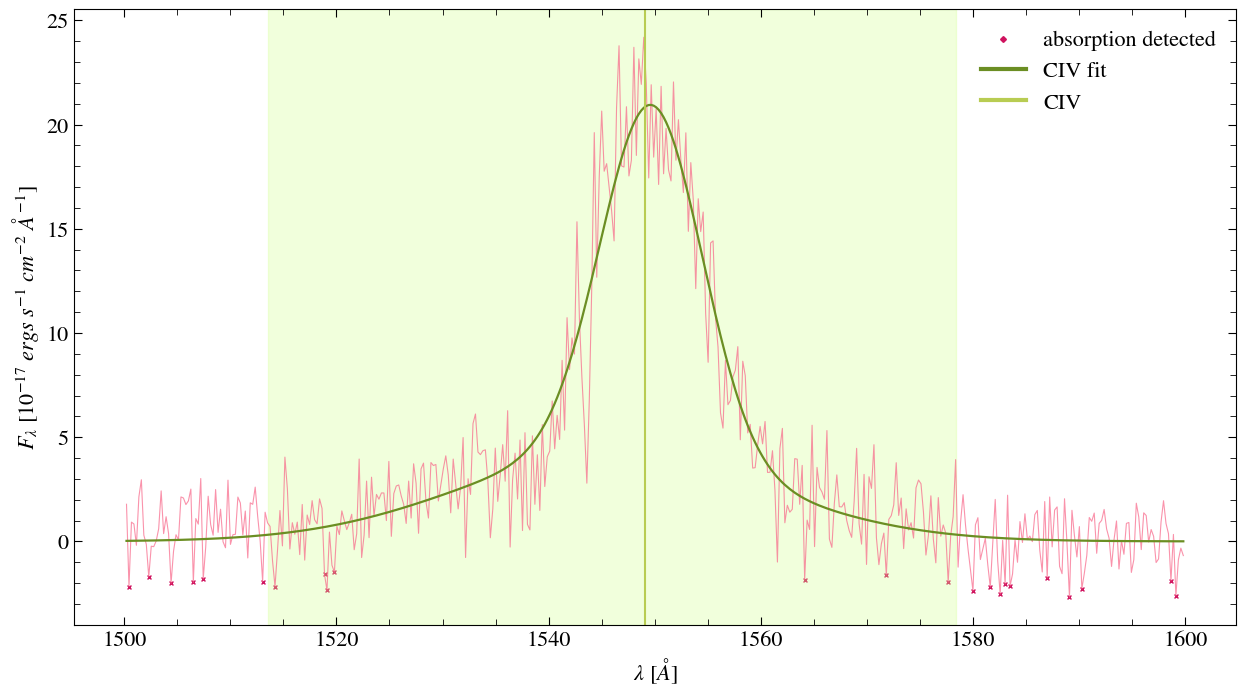

---------------------------------------
---------------------------------------

            SDSS: 085451.11+173009.1

            Lya:	106.662
            NV:		202.851	162.412 (Hamann)
            CIV:	148.139	120.014 (Hamann)
            
            compared to CIV:
            Lya		NV	CIV
            0.72	1.37	1
        


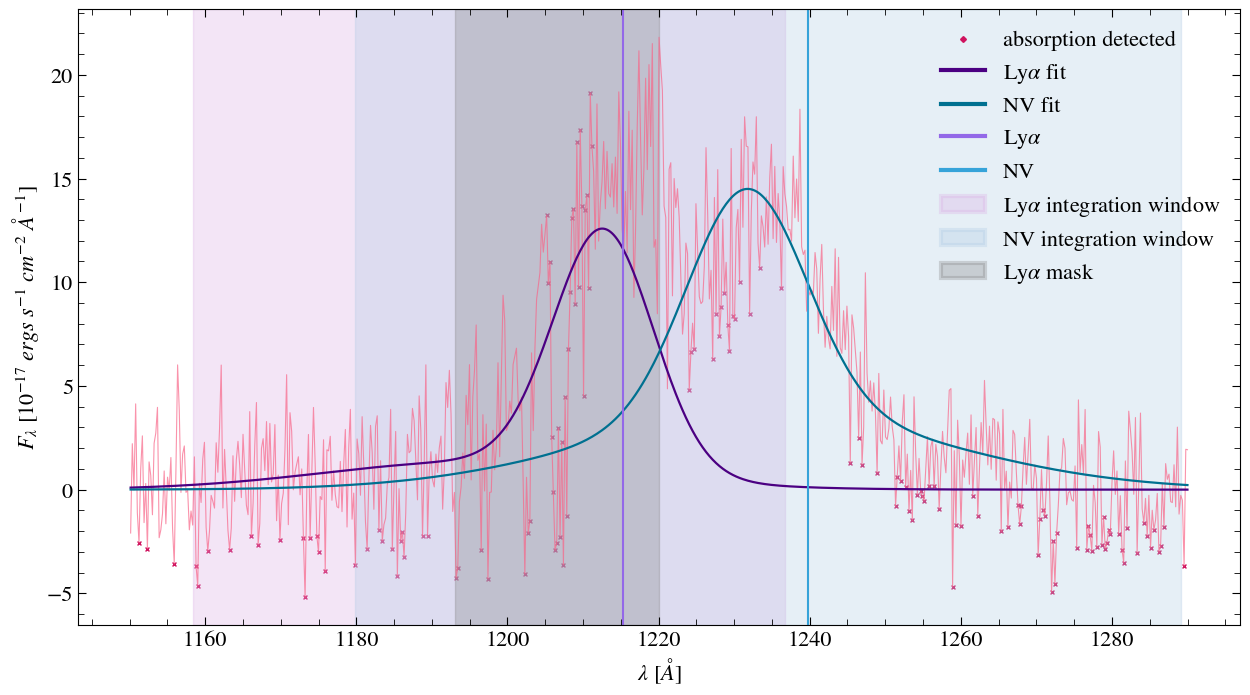

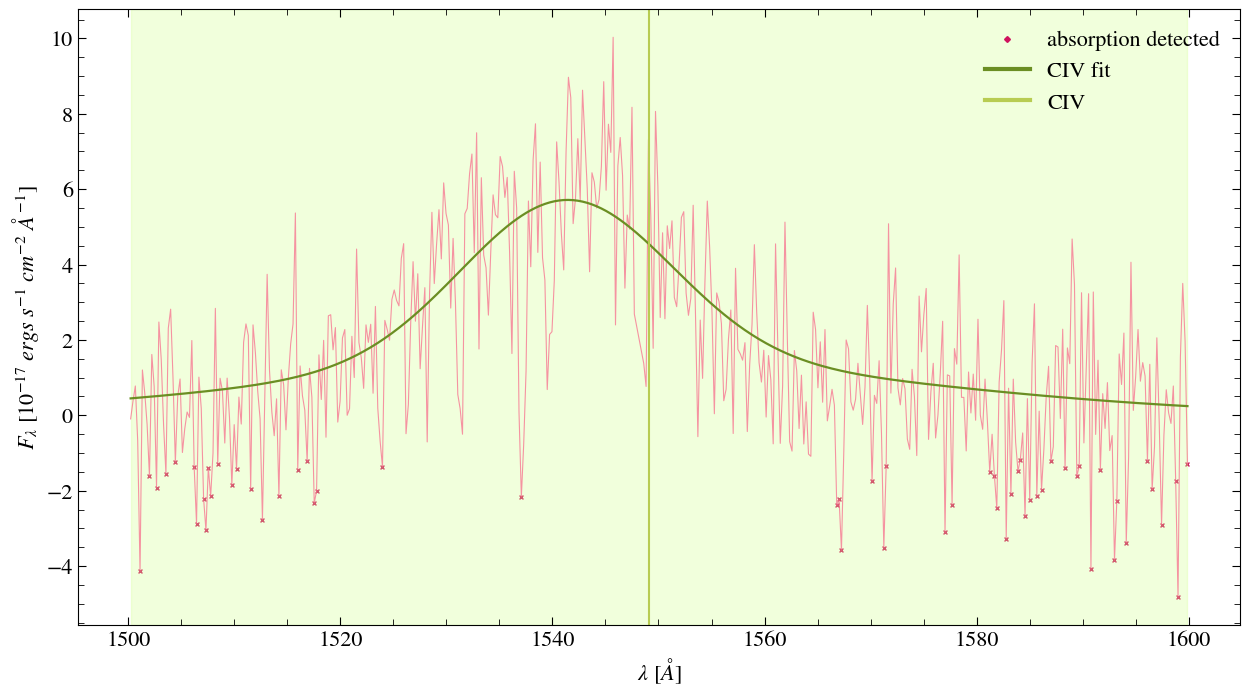

---------------------------------------
---------------------------------------

            SDSS: 102447.32-013633.8

            Lya:	256.143
            NV:		132.352	76.914 (Hamann)
            CIV:	76.906	192.349 (Hamann)
            
            compared to CIV:
            Lya		NV	CIV
            3.33	1.72	1
        


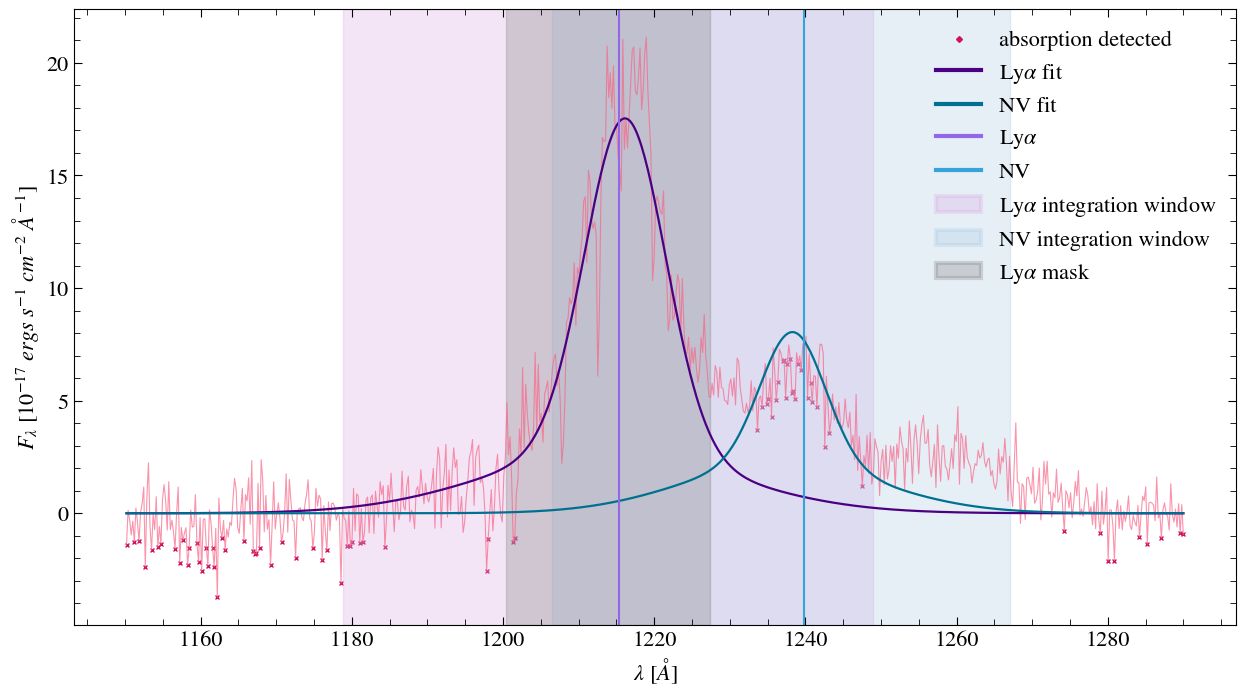

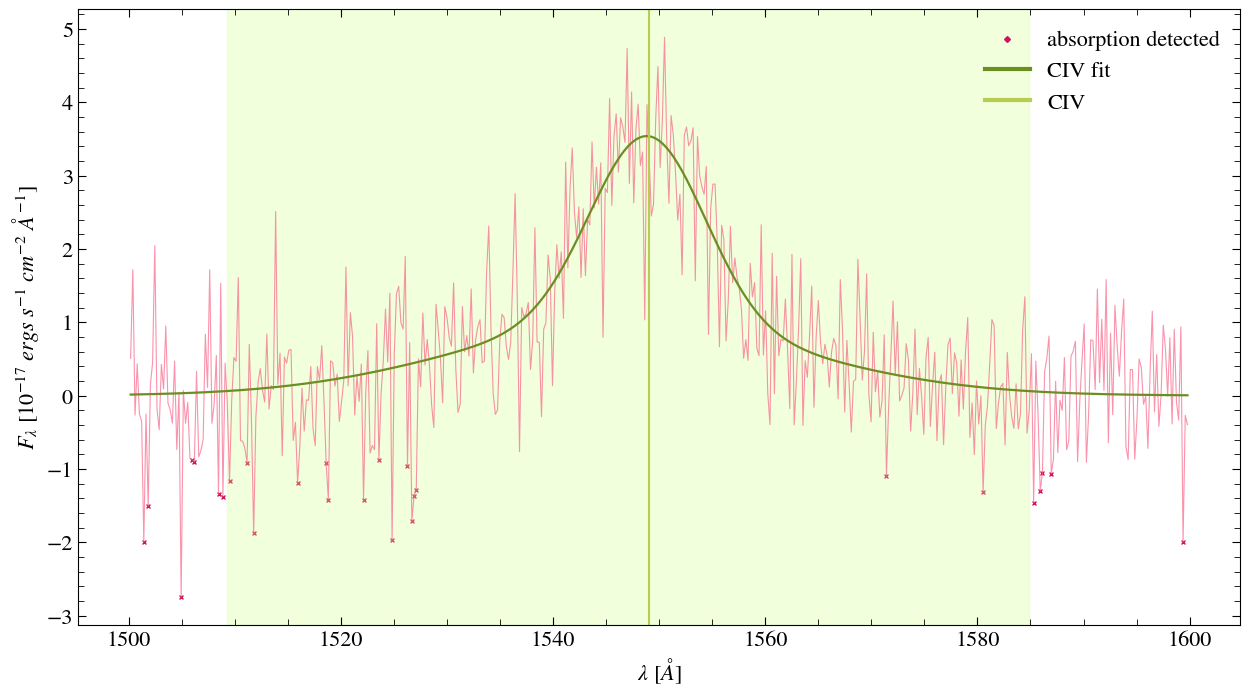

In [8]:
for i in range(len(data)):
    print("---------------------------------------\n---------------------------------------")
    test(i)

In [9]:
# stats = data[data["my_rew"].notnull()][['sdss_name','redshift', 'rew', 'fit_rew', 'fwhm', 'kt80', 'my_fwhm', 'my_rew', 'my_kt80']]

stats[['civ_fwhm_mine', 'civ_kt80_mine', 'civ_rew_mine', 'nv_rew_mine',
       'lya_rew_mine', 'civ_fit_rew_mine', 'nv_fit_rew_mine',
       'lya_fit_rew_mine']] = stats[['civ_fwhm_mine', 'civ_kt80_mine', 'civ_rew_mine', 'nv_rew_mine',
       'lya_rew_mine', 'civ_fit_rew_mine', 'nv_fit_rew_mine',
       'lya_fit_rew_mine']].astype(float)

stats["civ_rew_abs_diff"] = stats["civ_rew_mine"] - stats["civ_rew_hamann"]
stats["nv_rew_abs_diff"] = stats["nv_rew_mine"] - stats["nv_rew_hamann"]


stats["civ_rew_rel_diff"] = abs(stats["civ_rew_abs_diff"] / stats["civ_rew_hamann"])
stats["nv_rew_rel_diff"] = abs(stats["nv_rew_abs_diff"] / stats["nv_rew_hamann"])

stats[['civ_rew_abs_diff', 'nv_rew_abs_diff',
       'civ_rew_rel_diff', 'nv_rew_rel_diff']].describe()

,civ_rew_abs_diff,nv_rew_abs_diff,civ_rew_rel_diff,nv_rew_rel_diff
count,30.000000,29.000000,30.000000,29.000000
mean,-12.408274,-34.416593,0.181155,0.289692
std,46.182241,88.905589,0.160346,0.202387
min,-120.487687,-372.187695,0.003992,0.004815
25%,-22.654839,-48.127022,0.064262,0.146923
50%,-7.065423,-27.764594,0.136890,0.248990
75%,19.511976,24.175848,0.247113,0.384944
max,44.016596,58.885014,0.600175,0.800309


In [10]:
stats = stats.dropna(subset="civ_rew_mine")

current_stats_path = "data/local/desi_current_best_measurements.csv"

stats.to_csv(current_stats_path)